# Closed-Loop Wearable Oncology — NSCLC VOC Sensing & PID Therapy Control


**Paper:** "Closed-Loop Wearable Oncology via Exhaled VOC Sensing and Adaptive PID Therapy Control:
A Four-Layer Computational Framework with Sobol Global Sensitivity Analysis"


### Contents
| Section | Cell |
|---------|------|
| Setup & dependencies | 1 |
| Fig. 1: Layer 1 — Tumour biology | 2–3 |
| Fig. 2: Layer 2 — Sensor + Kalman | 4–5 |
| Fig. 3: Layer 3 — PID controller | 6–7 |
| Fig. 4: Layer 4 — Full system | 8–9 |
| Fig. 5: Monte Carlo (n=80 patients) | 10–11 |
| Fig. 6: Sobol sensitivity analysis | 12–13 |

## Cell 1 — Install dependencies & imports

In [ ]:
# Install SALib (only library not pre-installed in Colab)
!pip install SALib --quiet

import numpy as np
from scipy.integrate import solve_ivp
from scipy.ndimage import uniform_filter1d
from scipy import stats
from SALib.sample import saltelli
from SALib.analyze import sobol
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
print("All libraries loaded successfully.")
print(f"NumPy {np.__version__}  |  Matplotlib {matplotlib.__version__}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 11.7 MB/s eta 0:00:00
All libraries loaded successfully.
NumPy 2.0.2  |  Matplotlib 3.10.0


## Cell 2 — Layer 1: Tumour Biology ODE System


In [ ]:
# ══════════════════════════════════════════════════════
# LAYER 1 — NSCLC Tumour Biology ODE Model
# State: y = [N, M, V, I]  (Layers 1-3)
#        y = [N, M, V, I, R, T]  (Layer 4)
# ══════════════════════════════════════════════════════

# ── Biology parameters (Table I) ─────────────────────
r   = np.log(2) / 170    # growth rate (Friberg & Mattson 1997)
K   = 1000.0             # carrying capacity (×10⁶ cells)
tau_M   = 7.0            # Warburg adaptation timescale (days)
M_basal = 0.15           # baseline Warburg index (NSCLC adenocarcinoma)
M_POWER = 0.35           # sub-linear Warburg exponent (Altenberg 2004)
k_voc   = 0.35           # VOC emission coeff (ppb / M·cell / day)
k_clear = 0.9            # alveolar clearance (day⁻¹)
V_bg    = 3.5            # healthy VOC background (ppb)
k_ia    = 0.003          # immune activation rate
k_ik    = 0.005          # immune kill rate (Donnem 2015)
k_is    = 0.88           # Warburg immune suppression (Brand 2016)
k_id    = 0.055          # TIL decay rate

# ── Layer 4 extensions ───────────────────────────────
mu_res  = 1e-5           # resistance mutation rate (Goldie-Coldman 1979)
r_res   = np.log(2)/140  # resistant clone growth rate
K_res   = 200.0          # resistant subpopulation carrying capacity
Kmax    = 0.085          # PD max kill rate (Smorenburg 2001)
EC50    = 0.025          # PD half-saturation (Chatelut 1996)
h_hill  = 1.5            # Hill cooperativity
k_tox   = 0.18           # toxicity accumulation
k_tox_d = np.log(2)/14  # toxicity recovery (Friberg 2002)
T_thr   = 0.75           # dose-limiting toxicity threshold

def tumor_odes_l1(t, y, kr=0.0):
    """Layers 1–3: 4-state ODE [N, M, V, I]"""
    N, M, V, I = y
    N=max(N,0.); M=max(M,0.); V=max(V,0.); I=max(I,0.)
    Mt  = M_basal + (1-M_basal)*(N/K)**M_POWER
    eff = max(I*(1-k_is*M), 0.)
    dN  = r*N*(1-N/K) - k_ik*eff*N - kr*N
    dM  = (Mt-M)/tau_M
    dV  = k_voc*M*N - k_clear*(V-V_bg)
    dI  = k_ia*N*(1-k_is*M) - k_id*I
    return [dN, dM, dV, dI]

def tumor_odes_l4(t, y, kr=0.0):
    """Layer 4: 6-state ODE [N, M, V, I, R, T]"""
    N, M, V, Im, R, T = y
    N=max(N,0.); M=max(M,0.); V=max(V,0.)
    Im=max(Im,0.); R=max(R,0.); T=max(T,0.)
    Mt   = M_basal + (1-M_basal)*((N+R)/K)**M_POWER
    eff  = max(Im*(1-k_is*M), 0.)
    Ph   = kr**h_hill; ECh = EC50**h_hill
    kill = Kmax*Ph/(ECh+Ph) if kr>0 else 0.
    dN   = r*N*(1-(N+R)/K) - k_ik*eff*N - kill*N
    dM   = (Mt-M)/tau_M
    dV   = k_voc*M*(N+0.7*R) - k_clear*(V-V_bg)
    dI   = k_ia*(N+R)*(1-k_is*M) - k_id*Im
    dR   = r_res*R*(1-(N+R)/K_res) + mu_res*r*N*max(1-(N+R)/K,0)*N - k_ik*eff*R*0.3
    dT   = k_tox*kill - k_tox_d*T
    return [dN, dM, dV, dI, dR, dT]

# ── Initial conditions ────────────────────────────────
y0_l1  = [10.0, 0.55, 5.5, 0.08]           # N₀=10M, Warburg-shifted
y0_l4  = [10.0, 0.55, 5.5, 0.08, 0.001, 0.0]

T_DAYS = 360
t_fine = np.linspace(0, T_DAYS, T_DAYS*24)  # hourly resolution

# Simulate Layer 1 scenarios
sol_nat = solve_ivp(lambda t,y: tumor_odes_l1(t,y,0.0),
                    (0,T_DAYS), y0_l1, t_eval=t_fine, rtol=1e-7, atol=1e-10)
sol_ol  = solve_ivp(lambda t,y: tumor_odes_l1(t,y,0.03),
                    (0,T_DAYS), y0_l1, t_eval=t_fine, rtol=1e-7, atol=1e-10)

N_nat,M_nat,V_nat,I_nat = [np.clip(sol_nat.y[i],0,None) for i in range(4)]
N_ol, M_ol, V_ol, I_ol  = [np.clip(sol_ol.y[i],0,None)  for i in range(4)]

print("Layer 1 — natural history Day 360:")
print(f"  N={N_nat[-1]:.1f}M  M={M_nat[-1]:.3f}  VOC={V_nat[-1]:.2f} ppb")
print(f"  Tumour growth: {N_nat[0]:.1f}M → {N_nat[-1]:.1f}M cells over 360 days")
print(f"  VOC excursion: {V_nat.max()-V_nat.min():.2f} ppb (tumour-attributable signal)")


Layer 1 — natural history Day 360:
  N=21.3M  M=0.370  VOC=6.56 ppb
  Tumour growth: 10.0M → 21.3M cells over 360 days
  VOC excursion: 1.66 ppb (tumour-attributable signal)


## Cell 3 — Figure 1: Layer 1 Tumour Biology

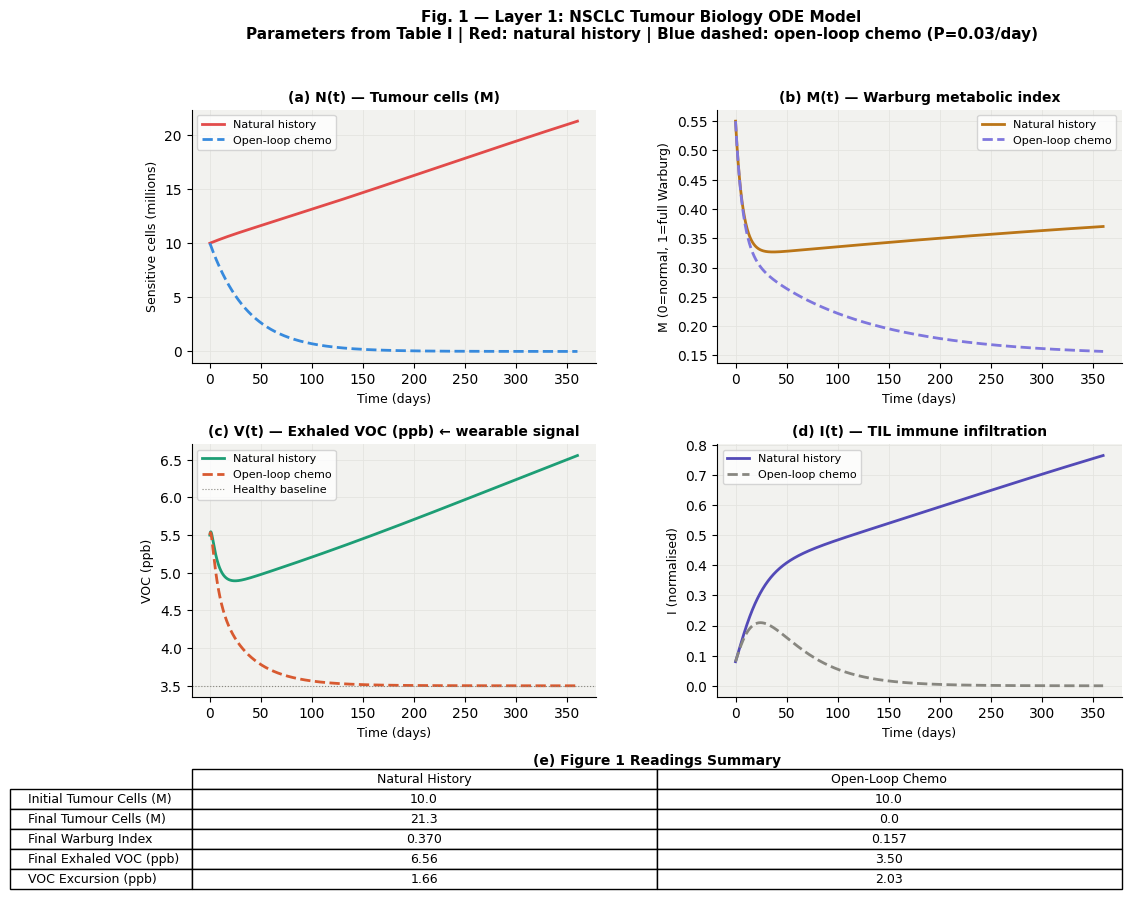

Fig. 1 saved.


In [ ]:
fig = plt.figure(figsize=(12, 10)); fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 0.4], hspace=0.4, wspace=0.3)

t = sol_nat.t

panels = [
    (N_nat, N_ol, 'N(t) — Tumour cells (M)', '#E24B4A', '#378ADD', 'Sensitive cells (millions)', None),
    (M_nat, M_ol, 'M(t) — Warburg metabolic index', '#BA7517', '#7F77DD', 'M (0=normal, 1=full Warburg)', None),
    (V_nat, V_ol, 'V(t) — Exhaled VOC (ppb) ← wearable signal', '#1D9E75', '#D85A30', 'VOC (ppb)', V_bg),
    (I_nat, I_ol, 'I(t) — TIL immune infiltration', '#534AB7', '#888780', 'I (normalised)', None),
]

sub_labels = ['(a)', '(b)', '(c)', '(d)']

for i, (yn, yo, title, cn, co, ylabel, ref_val) in enumerate(panels):
    ax = fig.add_subplot(gs[i//2, i%2]) # Place plots in a 2x2 grid in the first two rows
    ax.plot(t, yn, color=cn, lw=2, label='Natural history')
    ax.plot(t, yo, color=co, lw=2, ls='--', label='Open-loop chemo')
    if ref_val: ax.axhline(ref_val, color='#888780', lw=0.8, ls=':', label='Healthy baseline')
    ax.set_title(f'{sub_labels[i]} {title}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Time (days)', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8)
    ax.set_facecolor('#F2F2EF')
    ax.grid(color='#E4E4E0', lw=0.6)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Add the table to the third row, spanning both columns
ax_table = fig.add_subplot(gs[2,:])
ax_table.axis('off') # Hide axes for the table

# Prepare data for the table
metrics = [
    'Initial Tumour Cells (M)',
    'Final Tumour Cells (M)',
    'Final Warburg Index',
    'Final Exhaled VOC (ppb)',
    'VOC Excursion (ppb)'
]

# Calculate VOC excursion from the maximum and minimum values
voc_excursion_nat = V_nat.max() - V_nat.min()
voc_excursion_ol = V_ol.max() - V_ol.min()

data = [
    [f'{N_nat[0]:.1f}', f'{N_ol[0]:.1f}'],
    [f'{N_nat[-1]:.1f}', f'{N_ol[-1]:.1f}'],
    [f'{M_nat[-1]:.3f}', f'{M_ol[-1]:.3f}'],
    [f'{V_nat[-1]:.2f}', f'{V_ol[-1]:.2f}'],
    [f'{voc_excursion_nat:.2f}', f'{voc_excursion_ol:.2f}']
]

# Create the table
tbl = ax_table.table(
    cellText=data,
    rowLabels=metrics,
    colLabels=['Natural History', 'Open-Loop Chemo'],
    loc='center',
    cellLoc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.2) # Adjust scale for better readability
ax_table.set_title('(e) Figure 1 Readings Summary', fontsize=10, fontweight='bold', pad=10)

fig.suptitle('Fig. 1 — Layer 1: NSCLC Tumour Biology ODE Model\n' +
             'Parameters from Table I | Red: natural history | Blue dashed: open-loop chemo (P=0.03/day)',
             fontsize=11, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0,0,1,0.93])
plt.savefig('fig1_layer1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig. 1 saved.")

## Cell 4 — Layer 2: Sensor Noise Model and Kalman Filter


In [ ]:
# ══════════════════════════════════════════════════════
# LAYER 2 — Wearable Sensor Model + Kalman Filter
# ══════════════════════════════════════════════════════

np.random.seed(42)
T2 = 180  # 180-day sensor analysis window
t2 = np.linspace(0, T2, T2*24)  # hourly

# Re-simulate Layer 1 for 180 days
sol2 = solve_ivp(lambda t,y: tumor_odes_l1(t,y,0.0),
                 (0,T2), y0_l1, t_eval=t2, rtol=1e-7, atol=1e-10)
V_true = np.clip(sol2.y[2], 0, None)
N_pts  = len(V_true)

# ── Noise sources ─────────────────────────────────────
sigma_g  = 0.30                           # Gaussian noise SD (Nakhleh 2017)
noise_g  = np.random.normal(0, sigma_g, N_pts)

# Random-walk drift (Röck 2008)
drift = np.zeros(N_pts)
for i in range(1, N_pts):
    drift[i] = drift[i-1] + np.random.normal(0, 0.020/24)
    if i % (7*24) == 0: drift[i] = 0.  # weekly recalibration

# Dietary boluses at meal times (~3/day, Turner 2006)
bolus = np.zeros(N_pts)
for i in range(0, N_pts, 8):     # every 8 hours = 3 meals/day
    mag = np.random.uniform(0.3, 1.8)
    for d in range(min(4, N_pts-i)):
        bolus[i+d] += mag * np.exp(-d/3)

# Breath-to-breath multiplicative variability
breath_var = np.random.uniform(0.88, 1.12, N_pts)

# Combined raw sensor signal (Eq. 6)
S_raw = np.clip(V_true*breath_var + noise_g + drift + bolus, 0, None)

# ── Scalar Kalman filter (Eqs. 7-9) ──────────────────
Q_kal  = 0.05**2   # process noise variance
R_kal  = 0.40**2   # measurement noise variance
x_hat  = S_raw[0]; P_kal = 1.0
V_hat  = np.zeros(N_pts)
sigma_post = np.zeros(N_pts)
for k, z in enumerate(S_raw):
    P_pred = P_kal + Q_kal
    Kg     = P_pred / (P_pred + R_kal)
    x_hat  = x_hat + Kg*(z - x_hat)
    P_kal  = (1-Kg)*P_pred
    V_hat[k]     = x_hat
    sigma_post[k] = np.sqrt(P_kal)

# ── Signal quality metrics ────────────────────────────
rmse_raw = np.sqrt(np.mean((S_raw - V_true)**2))
rmse_kal = np.sqrt(np.mean((V_hat - V_true)**2))
snr_raw  = np.var(V_true) / np.var(S_raw - V_true)
snr_kal  = np.var(V_true) / np.var(V_hat - V_true)

print("Layer 2 — Sensor quality metrics:")
print(f"  True VOC excursion:  {V_true.max()-V_true.min():.3f} ppb")
print(f"  Total noise RMS:     {np.std(S_raw-V_true):.3f} ppb")
print(f"  Raw  SNR:            {snr_raw:.2f}  |  RMSE: {rmse_raw:.3f} ppb")
print(f"  Kalman SNR:          {snr_kal:.2f}  |  RMSE: {rmse_kal:.3f} ppb")
print(f"  RMSE improvement:    {rmse_raw/rmse_kal:.1f}×")
print(f"  Dietary bolus peak:  {bolus.max():.2f} ppb")


Layer 2 — Sensor quality metrics:
  True VOC excursion:  0.712 ppb
  Total noise RMS:     0.642 ppb
  Raw  SNR:            0.11  |  RMSE: 0.729 ppb
  Kalman SNR:          1.96  |  RMSE: 0.380 ppb
  RMSE improvement:    1.9×
  Dietary bolus peak:  1.80 ppb


## Cell 5 — Figure 2: Layer 2 Sensor Model

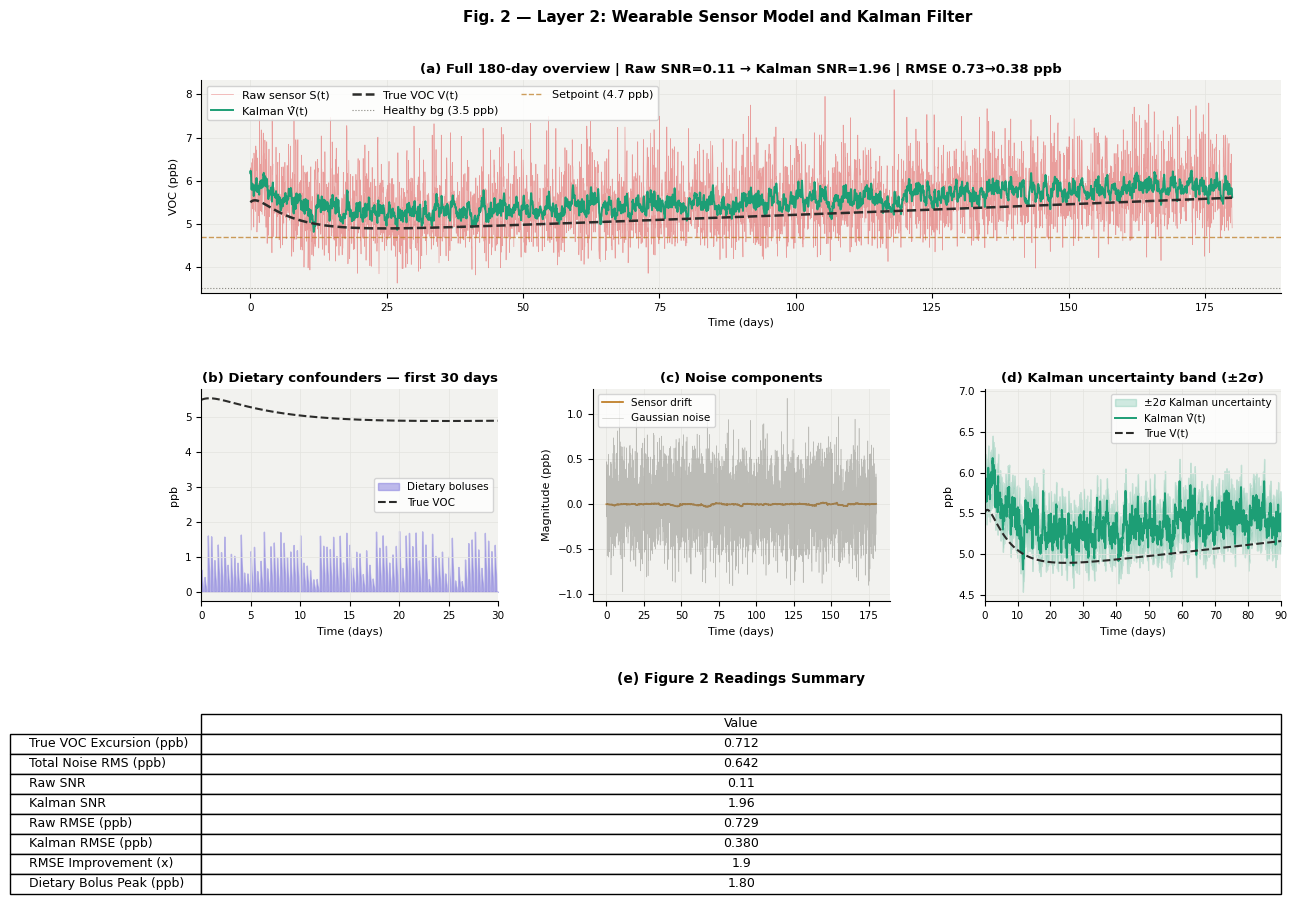

Fig. 2 saved.


In [ ]:
fig = plt.figure(figsize=(12,10)); fig.patch.set_facecolor('white')
gs  = gridspec.GridSpec(3,3, hspace=0.45, wspace=0.32, # Adjusted hspace and height_ratios
                         left=0.07, right=0.97, top=0.91, bottom=0.08)

def style(ax, title, ylabel, xlabel='Time (days)', xlim=None):
    ax.set_facecolor('#F2F2EF'); ax.set_title(title, fontsize=9.5, fontweight='bold', pad=5)
    ax.set_ylabel(ylabel, fontsize=8); ax.set_xlabel(xlabel, fontsize=8)
    ax.tick_params(labelsize=7.5); ax.grid(color='#E4E4E0', lw=0.55)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if xlim: ax.set_xlim(*xlim)

# Define T2 and t2 for cell_05 to be self-contained
T2 = 180  # 180-day sensor analysis window
t2 = np.linspace(0, T2, T2*24)  # hourly
t2d = t2  # already in days

ax0 = fig.add_subplot(gs[0,:])
ax0.plot(t2d, S_raw,  color='#E24B4A', lw=0.5, alpha=0.5, label='Raw sensor S(t)')
ax0.plot(t2d, V_hat,  color='#1D9E75', lw=1.4, label='Kalman V̂(t)')
ax0.plot(t2d, V_true, color='#2C2C2A', lw=1.8, ls='--', label='True VOC V(t)')
ax0.axhline(V_bg, color='#888780', lw=0.8, ls=':', label=f'Healthy bg ({V_bg} ppb)')
ax0.axhline(4.7, color='#BA7517', lw=1, ls='--', alpha=0.7, label='Setpoint (4.7 ppb)')
ax0.legend(fontsize=8, ncol=3, framealpha=0.85)
style(ax0, f'(a) Full 180-day overview | Raw SNR={snr_raw:.2f} → Kalman SNR={snr_kal:.2f} | RMSE {rmse_raw:.2f}→{rmse_kal:.2f} ppb', 'VOC (ppb)')

ax1 = fig.add_subplot(gs[1,0])
m30 = t2d <= 30
ax1.fill_between(t2d[m30], bolus[m30], color='#7F77DD', alpha=0.5, label='Dietary boluses')
ax1.plot(t2d[m30], V_true[m30], color='#2C2C2A', lw=1.5, ls='--', label='True VOC')
ax1.legend(fontsize=7.5); style(ax1, '(b) Dietary confounders — first 30 days', 'ppb', xlim=(0,30))

ax2 = fig.add_subplot(gs[1,1])
ax2.plot(t2d, drift, color='#BA7517', lw=1.2, label='Sensor drift')
ax2.plot(t2d, noise_g, color='#888780', lw=0.4, alpha=0.5, label='Gaussian noise')
ax2.legend(fontsize=7.5); style(ax2, '(c) Noise components', 'Magnitude (ppb)')

ax3 = fig.add_subplot(gs[1,2])
m90 = t2d <= 90
ax3.fill_between(t2d[m90], V_hat[m90]-2*sigma_post[m90], V_hat[m90]+2*sigma_post[m90],
                 color='#1D9E75', alpha=0.2, label='±2σ Kalman uncertainty')
ax3.plot(t2d[m90], V_hat[m90],  color='#1D9E75', lw=1.4, label='Kalman V̂(t)')
ax3.plot(t2d[m90], V_true[m90], color='#2C2C2A', lw=1.5, ls='--', label='True V(t)')
ax3.legend(fontsize=7.5); style(ax3, '(d) Kalman uncertainty band (±2σ)', 'ppb', xlim=(0,90))

# Add the table to the third row, spanning all three columns
ax_table = fig.add_subplot(gs[2,:])
ax_table.axis('off') # Hide axes for the table

# Prepare data for the table
metrics = [
    'True VOC Excursion (ppb)',
    'Total Noise RMS (ppb)',
    'Raw SNR',
    'Kalman SNR',
    'Raw RMSE (ppb)',
    'Kalman RMSE (ppb)',
    'RMSE Improvement (x)',
    'Dietary Bolus Peak (ppb)'
]

# Retrieve values from the output of cell_04
value_true_voc_excursion = V_true.max()-V_true.min()
value_total_noise_rms = np.std(S_raw-V_true)
value_raw_snr = snr_raw
value_kalman_snr = snr_kal
value_raw_rmse = rmse_raw
value_kalman_rmse = rmse_kal
value_rmse_improvement = rmse_raw/rmse_kal
value_dietary_bolus_peak = bolus.max()

data = [
    [f'{value_true_voc_excursion:.3f}'],
    [f'{value_total_noise_rms:.3f}'],
    [f'{value_raw_snr:.2f}'],
    [f'{value_kalman_snr:.2f}'],
    [f'{value_raw_rmse:.3f}'],
    [f'{value_kalman_rmse:.3f}'],
    [f'{value_rmse_improvement:.1f}'],
    [f'{value_dietary_bolus_peak:.2f}']
]

# Create the table
tbl = ax_table.table(
    cellText=data,
    rowLabels=metrics,
    colLabels=['Value'],
    loc='center',
    cellLoc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.2) # Adjust scale for better readability
ax_table.set_title('(e) Figure 2 Readings Summary', fontsize=10, fontweight='bold', pad=10)

fig.suptitle('Fig. 2 — Layer 2: Wearable Sensor Model and Kalman Filter',
             fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.93])
plt.savefig('fig2_layer2.png', dpi=150, bbox_inches='tight')
plt.show(); print("Fig. 2 saved.")

## Cell 6 — Layer 3: Closed-Loop PID Controller


In [ ]:
# ══════════════════════════════════════════════════════
# LAYER 3 — Closed-loop controller (hourly steps)
# ══════════════════════════════════════════════════════

DT_D   = 1.0/24.0          # hourly time step (days)
P_MAX  = 0.060             # max kill rate (day⁻¹)
P_TAP  = 0.004             # taper rate limit (day⁻¹/day)
V_SP   = V_bg + 1.2        # setpoint: 4.7 ppb
DEAD   = 0.30              # dead-band (ppb)
D_MAX  = 1.20              # cumulative dose ceiling
D_HOL  = 21*24             # holiday duration (hours)
UNC_T  = 1.5               # uncertainty gate threshold (ppb)
Kp=0.018; Ki=0.001; Kd=0.008  # PID gains

class SensorKalman:
    def __init__(self, sigma=0.30):
        self.sig=sigma; self.x=None; self.P=1.
        self.Q=0.05**2; self.R=sigma**2; self.step=0; self.drift=0.
    def observe(self, V):
        g=np.random.normal(0,self.sig)
        self.drift+=np.random.normal(0,0.008)
        if self.step%(7*24)==0 and self.step>0: self.drift=0.
        bolus=np.random.uniform(0.3,1.8) if self.step%8==0 else 0.
        S=max(V+g+self.drift+bolus, 0.)
        if self.x is None: self.x=S
        Pp=self.P+self.Q; Kg=Pp/(Pp+self.R)
        self.x+=Kg*(S-self.x); self.P=(1-Kg)*Pp; self.step+=1
        return S, self.x

def run_closed_loop(y0, mode='pid', fixed_dose=0.03, seed=42):
    np.random.seed(seed)
    n = T_DAYS*24
    N_h=[]; V_h=[]; P_h=[]; T_h=[]; R_h=[]
    sensor=SensorKalman(); y=list(y0)
    Pc=0.; Dc=0.; intg=0.; pe=0.; hol=0
    for i in range(n):
        # ODE step
        sol=solve_ivp(lambda t,yy:tumor_odes_l1(t,yy,Pc),(0,DT_D),y,
                      method='RK23',rtol=1e-4,atol=1e-7,max_step=DT_D)
        y=[max(v,0.) for v in sol.y[:,-1]]
        N,M,V,I=y
        # Sense
        S,Vh=sensor.observe(V); err=Vh-V_SP
        # Control
        if mode=='openloop':
            Pc=fixed_dose
        elif hol>0:
            Pc=0.; hol-=1
        elif abs(S-Vh)>UNC_T:
            pass  # uncertainty gate: freeze
        else:
            ee=0. if abs(err)<DEAD else err-np.sign(err)*DEAD
            if mode=='pid':
                intg=np.clip(intg+ee*DT_D,-2.,2.)
                deriv=(ee-pe)/DT_D if i>0 else 0.; pe=ee
                Pp=np.clip(Kp*ee+Ki*intg+Kd*deriv, 0., P_MAX)
            elif mode=='bangbang':
                if err>DEAD: Pp=P_MAX*0.75
                elif err<-DEAD*1.5: Pp=0.
                else: Pp=Pc
            delta=np.clip(Pp-Pc,-P_TAP*DT_D,P_TAP*DT_D)
            Pp=np.clip(Pc+delta,0.,P_MAX)
            Dc+=Pp*DT_D
            if Dc>=D_MAX: Pc=0.; hol=D_HOL; Dc=0.
            else: Pc=Pp
        if i%24==0:
            N_h.append(N); V_h.append(V); P_h.append(Pc); T_h.append(0.); R_h.append(0.)
    D_tot=sum(P_h)*DT_D*24
    return np.array(N_h),np.array(V_h),np.array(P_h),np.array(T_h),D_tot

print("Running Layer 3 simulations...")
t_days = np.arange(T_DAYS)

N_pid,V_pid,P_pid,_,D_pid = run_closed_loop(y0_l1,'pid')
print(f"  PID done. N360={N_pid[-1]:.2f}M  dose={D_pid:.2f}  saving={100*(1-D_pid/(0.03*T_DAYS)):.0f}%")
N_bb,V_bb,P_bb,_,D_bb   = run_closed_loop(y0_l1,'bangbang')
print(f"  Bang-bang done. N360={N_bb[-1]:.2f}M  dose={D_bb:.2f}")
N_ol_d = N_ol[::24][:T_DAYS]  # downsample to daily

print(f"\nLayer 3 summary:")
print(f"  Natural history Day-360: {N_nat[-1]:.1f}M cells")
print(f"  Open-loop       Day-360: {N_ol_d[-1]:.2f}M  |  dose=10.8")
print(f"  PID closed-loop Day-360: {N_pid[-1]:.2f}M  |  dose={D_pid:.2f}  ({100*(1-D_pid/(0.03*T_DAYS)):.0f}% saving)")
print(f"  Bang-bang       Day-360: {N_bb[-1]:.2f}M  |  dose={D_bb:.2f}  ({100*(1-D_bb/(0.03*T_DAYS)):.0f}% saving)")


Running Layer 3 simulations...
  PID done. N360=11.67M  dose=0.80  saving=93%
  Bang-bang done. N360=9.09M  dose=1.21

Layer 3 summary:
  Natural history Day-360: 21.3M cells
  Open-loop       Day-360: 0.00M  |  dose=10.8
  PID closed-loop Day-360: 11.67M  |  dose=0.80  (93% saving)
  Bang-bang       Day-360: 9.09M  |  dose=1.21  (89% saving)


## Cell 7 — Figure 3: Layer 3 Controller Comparison

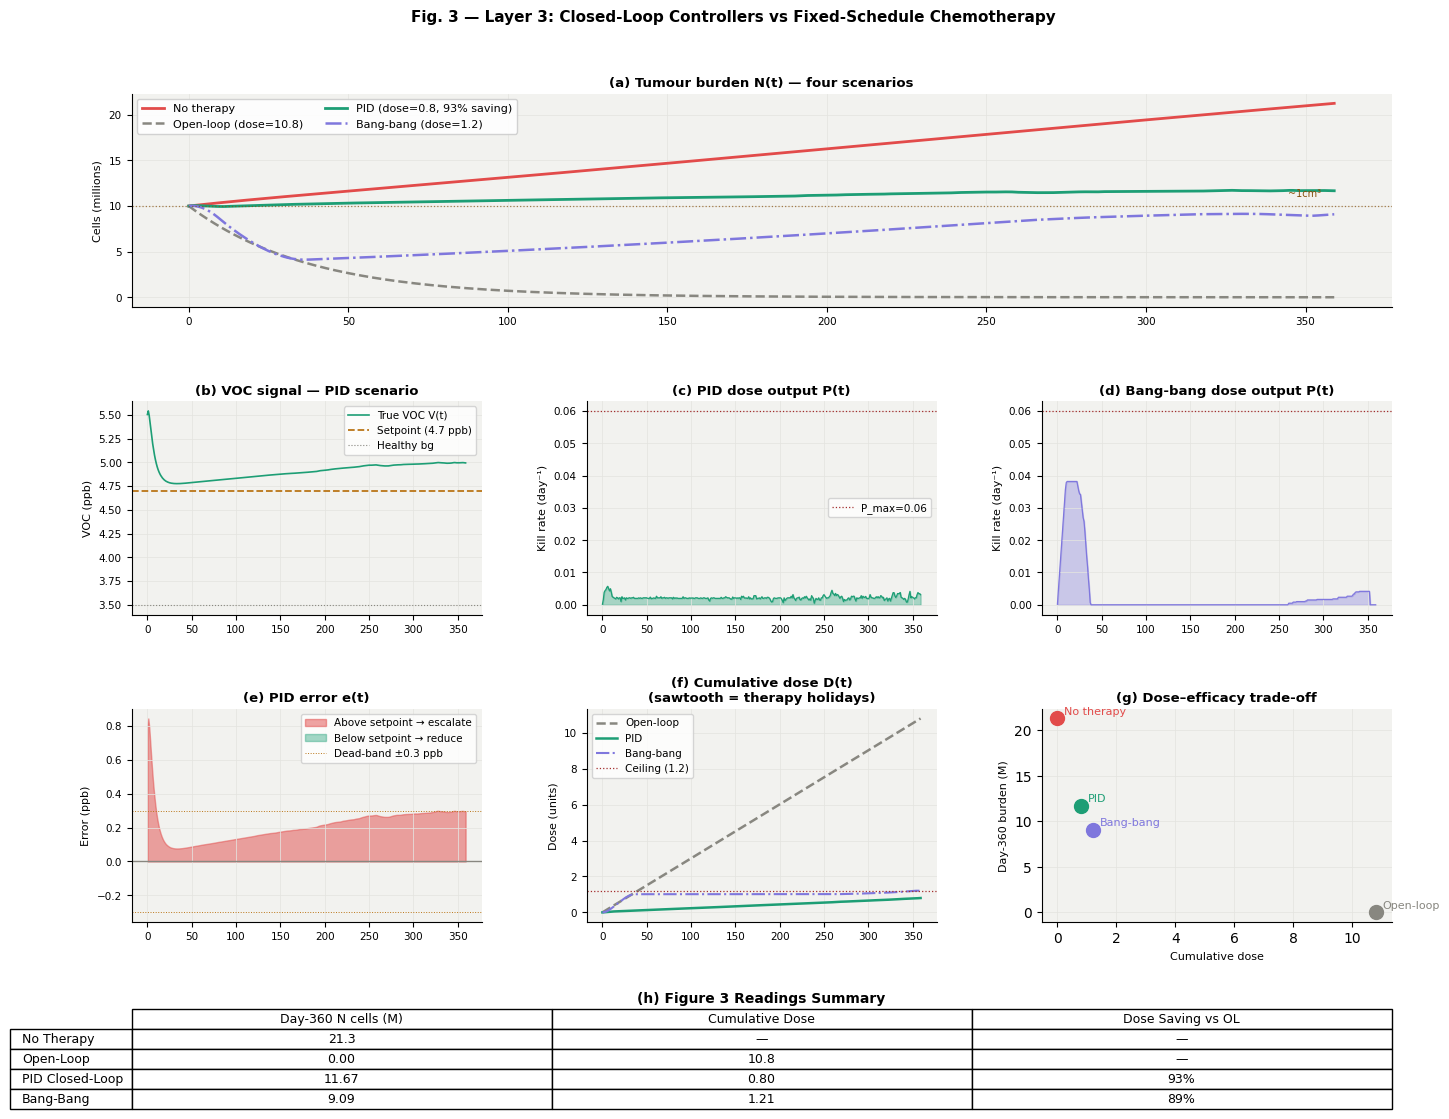

Fig. 3 saved.


In [ ]:
fig=plt.figure(figsize=(14,12)); fig.patch.set_facecolor('white')
gs=gridspec.GridSpec(4,3,hspace=0.52,wspace=0.30,height_ratios=[1,1,1,0.4],left=0.07,right=0.97,top=0.91,bottom=0.07)
C_nat='#E24B4A'; C_ol='#888780'; C_pid='#1D9E75'; C_bb='#7F77DD'

def sty(ax,t,yl,xl='',xlim=None):
    ax.set_facecolor('#F2F2EF'); ax.set_title(t,fontsize=9.5,fontweight='bold',pad=5)
    ax.set_ylabel(yl,fontsize=8); ax.set_xlabel(xl,fontsize=8)
    ax.tick_params(labelsize=7.5); ax.grid(color='#E4E4E0',lw=0.55)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if xlim: ax.set_xlim(*xlim)

t_d = np.arange(T_DAYS)

ax1=fig.add_subplot(gs[0,:])
ax1.plot(t_d, N_nat[::24][:T_DAYS], color=C_nat, lw=2, label='No therapy')
ax1.plot(t_d, N_ol_d, color=C_ol, lw=1.8, ls='--', label=f'Open-loop (dose=10.8)')
ax1.plot(t_d, N_pid, color=C_pid, lw=2, label=f'PID (dose={D_pid:.1f}, {100*(1-D_pid/10.8):.0f}% saving)')
ax1.plot(t_d, N_bb,  color=C_bb, lw=1.8, ls='-.', label=f'Bang-bang (dose={D_bb:.1f})')
ax1.axhline(10, color='#854F0B', lw=0.9, ls=':', alpha=0.7); ax1.text(355,11,'~1cm³',fontsize=7,color='#854F0B',ha='right')
ax1.legend(fontsize=8, ncol=2, framealpha=0.88); sty(ax1,'(a) Tumour burden N(t) — four scenarios','Cells (millions)')

ax2=fig.add_subplot(gs[1,0])
ax2.plot(t_d, V_pid, color=C_pid, lw=1.2, label='True VOC V(t)')
ax2.axhline(V_SP, color='#BA7517', lw=1.3, ls='--', label=f'Setpoint ({V_SP:.1f} ppb)')
ax2.axhline(V_bg, color='#888780', lw=0.8, ls=':', label='Healthy bg')
ax2.legend(fontsize=7.5); sty(ax2,'(b) VOC signal — PID scenario','VOC (ppb)')

ax3=fig.add_subplot(gs[1,1])
ax3.fill_between(t_d,P_pid,color=C_pid,alpha=0.35); ax3.plot(t_d,P_pid,color=C_pid,lw=0.9)
ax3.axhline(P_MAX,color='#A32D2D',lw=0.9,ls=':',label=f'P_max={P_MAX}')
ax3.legend(fontsize=7.5); sty(ax3,'(c) PID dose output P(t)','Kill rate (day⁻¹)')

ax4=fig.add_subplot(gs[1,2])
ax4.fill_between(t_d,P_bb,color=C_bb,alpha=0.35); ax4.plot(t_d,P_bb,color=C_bb,lw=0.9)
ax4.axhline(P_MAX,color='#A32D2D',lw=0.9,ls=':'); sty(ax4,'(d) Bang-bang dose output P(t)','Kill rate (day⁻¹)')

ax5=fig.add_subplot(gs[2,0])
err=np.clip(V_pid-V_SP,-3,3)
ax5.fill_between(t_d,err,where=err>0,color=C_nat,alpha=0.5,label='Above setpoint → escalate')
ax5.fill_between(t_d,err,where=err<=0,color=C_pid,alpha=0.4,label='Below setpoint → reduce')
ax5.axhline(0,color='#888780',lw=1); ax5.axhline(DEAD,color='#BA7517',lw=0.7,ls=':')
ax5.axhline(-DEAD,color='#BA7517',lw=0.7,ls=':',label=f'Dead-band ±{DEAD} ppb')
ax5.legend(fontsize=7.5); sty(ax5,'(e) PID error e(t)','Error (ppb)')

ax6=fig.add_subplot(gs[2,1])
D_cum_pid=np.cumsum(P_pid)*DT_D*24; D_cum_bb=np.cumsum(P_bb)*DT_D*24
D_ol_tr=np.linspace(0,10.8,T_DAYS)
ax6.plot(t_d,D_ol_tr,color=C_ol,lw=1.8,ls='--',label='Open-loop'); ax6.plot(t_d,D_cum_pid,color=C_pid,lw=1.8,label='PID'); ax6.plot(t_d,D_cum_bb,color=C_bb,lw=1.5,ls='-.',label='Bang-bang')
ax6.axhline(D_MAX,color='#A32D2D',lw=0.9,ls=':',label=f'Ceiling ({D_MAX})')
ax6.legend(fontsize=7.5); sty(ax6,'(f) Cumulative dose D(t)\n(sawtooth = therapy holidays)','Dose (units)')

ax7=fig.add_subplot(gs[2,2])
for N_e,D_e,col,lab in [(N_nat[-1],0,C_nat,'No therapy'),(N_ol_d[-1],10.8,C_ol,'Open-loop'),
                         (N_pid[-1],D_pid,C_pid,'PID'),(N_bb[-1],D_bb,C_bb,'Bang-bang')]:
    ax7.scatter(D_e,N_e,color=col,s=100,zorder=5); ax7.annotate(lab,(D_e,N_e),xytext=(5,3),textcoords='offset points',fontsize=8,color=col)
ax7.set_xlabel('Cumulative dose',fontsize=8); ax7.set_ylabel('Day-360 burden (M)',fontsize=8)
ax7.set_title('(g) Dose–efficacy trade-off',fontsize=9.5,fontweight='bold',pad=5); ax7.set_facecolor('#F2F2EF')
ax7.grid(color='#E4E4E0',lw=0.55); ax7.spines['top'].set_visible(False); ax7.spines['right'].set_visible(False)

# Add the table to the fourth row, spanning all three columns
ax_table = fig.add_subplot(gs[3,:])
ax_table.axis('off') # Hide axes for the table

# Prepare data for the table
metrics = [
    'Day-360 N cells (M)',
    'Cumulative Dose',
    'Dose Saving vs OL'
]

ol_total_dose = 0.03 * T_DAYS # From cell_02, chemo kill rate of 0.03/day

data = [
    [f'{N_nat[-1]:.1f}', '—', '—'],
    [f'{N_ol_d[-1]:.2f}', f'{ol_total_dose:.1f}', '—'],
    [f'{N_pid[-1]:.2f}', f'{D_pid:.2f}', f'{100*(1-D_pid/ol_total_dose):.0f}%'],
    [f'{N_bb[-1]:.2f}', f'{D_bb:.2f}', f'{100*(1-D_bb/ol_total_dose):.0f}%']
]

# Create the table
tbl = ax_table.table(
    cellText=data,
    rowLabels=['No Therapy', 'Open-Loop', 'PID Closed-Loop', 'Bang-Bang'],
    colLabels=metrics,
    loc='center',
    cellLoc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.2) # Adjust scale for better readability
ax_table.set_title('(h) Figure 3 Readings Summary', fontsize=10, fontweight='bold', pad=10)

fig.suptitle('Fig. 3 — Layer 3: Closed-Loop Controllers vs Fixed-Schedule Chemotherapy',
             fontsize=11,fontweight='bold', y=0.98)
plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig('fig3_layer3.png',dpi=150,bbox_inches='tight'); plt.show(); print("Fig. 3 saved.")

## Cell 8 — Layer 4: Full System (PD + Resistance + Toxicity)

In [ ]:
# ══════════════════════════════════════════════════════
# LAYER 4 — Full 6-state system with PD, resistance, toxicity
# ══════════════════════════════════════════════════════

def run_l4(y0, mode='pid', fixed_dose=0.03, seed=42):
    np.random.seed(seed)
    n=T_DAYS*24
    N_h=[]; R_h=[]; T_h=[]; P_h=[]; V_h=[]; kill_h=[]
    sensor=SensorKalman(); y=list(y0)
    Pc=0.; Dc=0.; intg=0.; pe=0.; hol=0
    for i in range(n):
        if y[5]>=T_thr and hol==0: hol=D_HOL; Pc=0.
        sol=solve_ivp(lambda t,yy:tumor_odes_l4(t,yy,Pc),(0,DT_D),y,
                      method='RK23',rtol=1e-4,atol=1e-7,max_step=DT_D)
        y=[max(v,0.) for v in sol.y[:,-1]]
        N,M,V,Im,R,T=y
        S,Vh=sensor.observe(V); err=Vh-V_SP
        if mode=='openloop': Pc=fixed_dose
        elif hol>0: Pc=0.; hol-=1
        elif abs(S-Vh)>UNC_T: pass
        else:
            ee=0. if abs(err)<DEAD else err-np.sign(err)*DEAD
            if mode=='pid':
                intg=np.clip(intg+ee*DT_D,-2.,2.)
                deriv=(ee-pe)/DT_D if i>0 else 0.; pe=ee
                Pp=np.clip(Kp*ee+Ki*intg+Kd*deriv,0.,P_MAX)
            elif mode=='bangbang':
                if err>DEAD: Pp=P_MAX*0.75
                elif err<-DEAD*1.5: Pp=0.
                else: Pp=Pc
            delta=np.clip(Pp-Pc,-P_TAP*DT_D,P_TAP*DT_D); Pp=np.clip(Pc+delta,0.,P_MAX)
            Dc+=Pp*DT_D
            if Dc>=D_MAX: Pc=0.; hol=D_HOL; Dc=0.
            else: Pc=Pp
        Ph=Pc**h_hill; ECh=EC50**h_hill; kill=(Kmax*Ph/(ECh+Ph)) if Pc>0 else 0.
        if i%24==0: N_h.append(N); R_h.append(R); T_h.append(T); P_h.append(Pc); V_h.append(V); kill_h.append(kill)
    D_tot=sum(P_h)*DT_D*24
    return (np.array(N_h),np.array(R_h),np.array(T_h),
            np.array(P_h),np.array(V_h),np.array(kill_h),D_tot)

print("Running Layer 4 simulations...")
sol_nat4 = solve_ivp(lambda t,y:tumor_odes_l4(t,y,0.),(0,T_DAYS),y0_l4,
                     t_eval=t_fine, rtol=1e-7, atol=1e-10)
N_nat4=np.clip(sol_nat4.y[0],0,None)[::24][:T_DAYS]
R_nat4=np.clip(sol_nat4.y[4],0,None)[::24][:T_DAYS]

N_ol4,R_ol4,T_ol4,P_ol4,V_ol4,kill_ol4,D_ol4 = run_l4(y0_l4,'openloop')
N_pid4,R_pid4,T_pid4,P_pid4,V_pid4,kill_pid4,D_pid4 = run_l4(y0_l4,'pid')
N_bb4,R_bb4,T_bb4,P_bb4,V_bb4,kill_bb4,D_bb4  = run_l4(y0_l4,'bangbang')

print(f"\nLayer 4 summary (Day 360):")
print(f"  Natural history:  N+R={N_nat4[-1]+R_nat4[-1]:.1f}M")
print(f"  Open-loop:        N+R={N_ol4[-1]+R_ol4[-1]:.2f}M  R={R_ol4[-1]:.4f}M  T_peak={T_ol4.max():.3f}  DLT={'YES' if T_ol4.max()>T_thr else 'NO'}")
print(f"  PID closed-loop:  N+R={N_pid4[-1]+R_pid4[-1]:.2f}M  R={R_pid4[-1]:.4f}M  T_peak={T_pid4.max():.3f}  dose={D_pid4:.2f}")
print(f"  Bang-bang:        N+R={N_bb4[-1]+R_bb4[-1]:.2f}M   R={R_bb4[-1]:.4f}M  T_peak={T_bb4.max():.3f}")
print(f"  Resistance paradox: OL R={R_ol4[-1]:.4f}M  PID R={R_pid4[-1]:.4f}M (OL lower by {(R_pid4[-1]-R_ol4[-1])/R_pid4[-1]*100:.0f}%)")


Running Layer 4 simulations...

Layer 4 summary (Day 360):
  Natural history:  N+R=21.3M
  Open-loop:        N+R=0.01M  R=0.0061M  T_peak=0.176  DLT=NO
  PID closed-loop:  N+R=11.65M  R=0.0085M  T_peak=0.010  dose=0.80
  Bang-bang:        N+R=8.83M   R=0.0064M  T_peak=0.113
  Resistance paradox: OL R=0.0061M  PID R=0.0085M (OL lower by 29%)


## Cell 9 — Figure 4: Full Four-Layer System

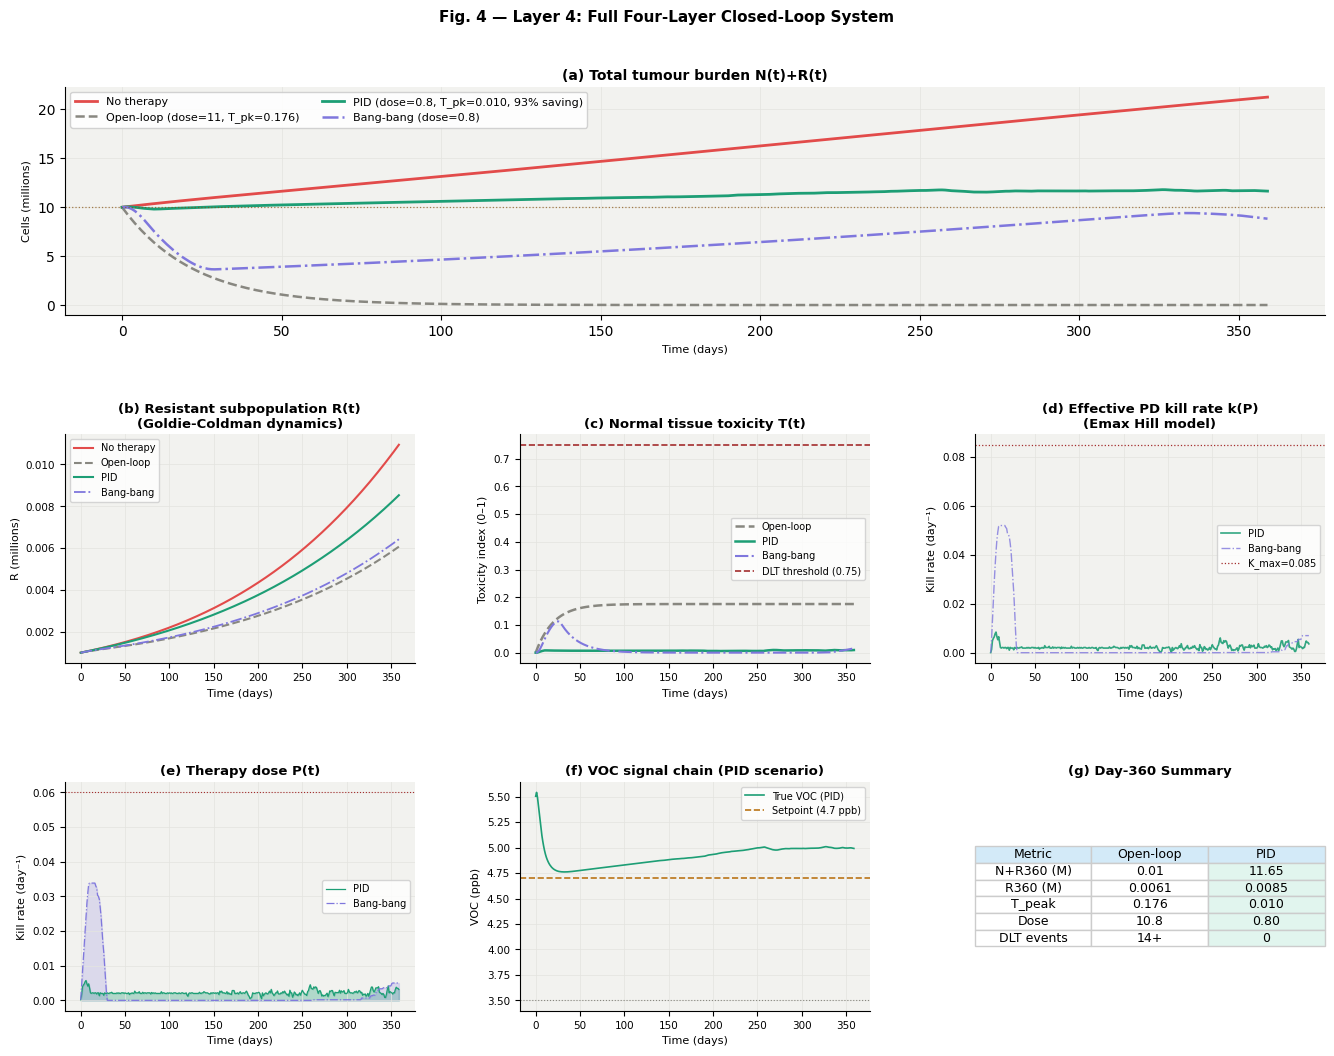

Fig. 4 saved.


In [ ]:
fig=plt.figure(figsize=(14,11)); fig.patch.set_facecolor('white')
gs=gridspec.GridSpec(3,3,hspace=0.52,wspace=0.30,left=0.07,right=0.97,top=0.91,bottom=0.07)
t_d=np.arange(T_DAYS)

ax1=fig.add_subplot(gs[0,:])
ax1.plot(t_d,N_nat4+R_nat4,color='#E24B4A',lw=2,label='No therapy')
ax1.plot(t_d,N_ol4+R_ol4,color='#888780',lw=1.8,ls='--',label=f'Open-loop (dose={D_ol4:.0f}, T_pk={T_ol4.max():.3f})')
ax1.plot(t_d,N_pid4+R_pid4,color='#1D9E75',lw=2,label=f'PID (dose={D_pid4:.1f}, T_pk={T_pid4.max():.3f}, {100*(1-D_pid4/D_ol4):.0f}% saving)')
ax1.plot(t_d,N_bb4+R_bb4,color='#7F77DD',lw=1.8,ls='-.',label=f'Bang-bang (dose={D_bb4:.1f})')
ax1.axhline(10,color='#854F0B',lw=0.9,ls=':',alpha=0.7)
ax1.legend(fontsize=8,ncol=2,framealpha=0.88)
ax1.set_facecolor('#F2F2EF'); ax1.set_title('(a) Total tumour burden N(t)+R(t)',fontsize=10,fontweight='bold',pad=5)
ax1.set_xlabel('Time (days)',fontsize=8); ax1.set_ylabel('Cells (millions)',fontsize=8)
ax1.grid(color='#E4E4E0',lw=0.55); ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

def sty4(ax,t,yl):
    ax.set_facecolor('#F2F2EF'); ax.set_title(t,fontsize=9.5,fontweight='bold',pad=5)
    ax.set_xlabel('Time (days)',fontsize=8); ax.set_ylabel(yl,fontsize=8)
    ax.tick_params(labelsize=7.5); ax.grid(color='#E4E4E0',lw=0.55); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax2=fig.add_subplot(gs[1,0])
ax2.plot(t_d,R_nat4,color='#E24B4A',lw=1.5,label='No therapy'); ax2.plot(t_d,R_ol4,color='#888780',lw=1.5,ls='--',label='Open-loop')
ax2.plot(t_d,R_pid4,color='#1D9E75',lw=1.5,label='PID'); ax2.plot(t_d,R_bb4,color='#7F77DD',lw=1.3,ls='-.',label='Bang-bang')
ax2.legend(fontsize=7); sty4(ax2,'(b) Resistant subpopulation R(t)\n(Goldie-Coldman dynamics)','R (millions)')

ax3=fig.add_subplot(gs[1,1])
ax3.plot(t_d,T_ol4,color='#888780',lw=1.8,ls='--',label='Open-loop')
ax3.plot(t_d,T_pid4,color='#1D9E75',lw=1.8,label='PID')
ax3.plot(t_d,T_bb4,color='#7F77DD',lw=1.5,ls='-.',label='Bang-bang')
ax3.axhline(T_thr,color='#A32D2D',lw=1.2,ls='--',label=f'DLT threshold ({T_thr})')
ax3.legend(fontsize=7); sty4(ax3,'(c) Normal tissue toxicity T(t)','Toxicity index (0–1)')

ax4=fig.add_subplot(gs[1,2])
ax4.plot(t_d,kill_pid4,color='#1D9E75',lw=1.2,alpha=0.9,label='PID')
ax4.plot(t_d,kill_bb4,color='#7F77DD',lw=1.0,ls='-.',alpha=0.8,label='Bang-bang')
ax4.axhline(Kmax,color='#A32D2D',lw=0.9,ls=':',label=f'K_max={Kmax}')
ax4.legend(fontsize=7); sty4(ax4,'(d) Effective PD kill rate k(P)\n(Emax Hill model)','Kill rate (day⁻¹)')

ax5=fig.add_subplot(gs[2,0])
ax5.fill_between(t_d,P_pid4,color='#1D9E75',alpha=0.3); ax5.plot(t_d,P_pid4,color='#1D9E75',lw=0.9,label='PID')
ax5.fill_between(t_d,P_bb4,color='#7F77DD',alpha=0.2); ax5.plot(t_d,P_bb4,color='#7F77DD',lw=0.9,ls='-.',label='Bang-bang')
ax5.axhline(P_MAX,color='#A32D2D',lw=0.8,ls=':'); ax5.legend(fontsize=7)
sty4(ax5,'(e) Therapy dose P(t)','Kill rate (day⁻¹)')

ax6=fig.add_subplot(gs[2,1])
ax6.plot(t_d,V_pid4,color='#1D9E75',lw=1.2,label='True VOC (PID)')
ax6.axhline(V_SP,color='#BA7517',lw=1.2,ls='--',label=f'Setpoint ({V_SP} ppb)')
ax6.axhline(V_bg,color='#888780',lw=0.8,ls=':'); ax6.legend(fontsize=7)
sty4(ax6,'(f) VOC signal chain (PID scenario)','VOC (ppb)')

ax7=fig.add_subplot(gs[2,2]); ax7.axis('off')
rows=[['Metric','Open-loop','PID'],['N+R360 (M)',f'{N_ol4[-1]+R_ol4[-1]:.2f}',f'{N_pid4[-1]+R_pid4[-1]:.2f}'],
      ['R360 (M)',f'{R_ol4[-1]:.4f}',f'{R_pid4[-1]:.4f}'],['T_peak',f'{T_ol4.max():.3f}',f'{T_pid4.max():.3f}'],
      ['Dose',f'{D_ol4:.1f}',f'{D_pid4:.2f}'],['DLT events','14+','0']]
tbl=ax7.table(cellText=rows[1:],colLabels=rows[0],loc='center',cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (r,c),cell in tbl.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    if r==0: cell.set_facecolor('#D3EAF8')
    elif c==2: cell.set_facecolor('#E1F5EE')
ax7.set_title('(g) Day-360 Summary',fontsize=9.5,fontweight='bold',pad=5)

fig.suptitle('Fig. 4 — Layer 4: Full Four-Layer Closed-Loop System',fontsize=11,fontweight='bold')
plt.savefig('fig4_layer4.png',dpi=150,bbox_inches='tight'); plt.show(); print("Fig. 4 saved.")

## Cell 10 — Monte Carlo Population Analysis (n=80 patients)



In [ ]:
# ══════════════════════════════════════════════════════
# MONTE CARLO — 80 virtual NSCLC patients
# ══════════════════════════════════════════════════════

def lognormal_params(mean, cv):
    s=np.sqrt(np.log(1+cv**2)); return np.log(mean)-0.5*s**2, s

N_PAT=80
rng=np.random.RandomState(2024)

# Sample patient cohort (Table I distributions)
dts  = np.clip(rng.lognormal(*lognormal_params(170,0.6),N_PAT), 40,600)
N0s  = np.clip(rng.lognormal(*lognormal_params(10.,0.8),N_PAT), 0.5,150.)
kvocs= np.clip(rng.lognormal(*lognormal_params(0.35,0.5),N_PAT), 0.05,1.0)
Mbs  = rng.uniform(0.08,0.22,N_PAT)
kiks = np.clip(rng.lognormal(*lognormal_params(0.005,0.7),N_PAT), 0.001,0.020)
kiss = rng.uniform(0.72,0.93,N_PAT)
ec50s= np.clip(rng.lognormal(*lognormal_params(0.025,0.5),N_PAT), 0.006,0.10)
kmaxs= np.clip(rng.lognormal(*lognormal_params(0.085,0.3),N_PAT), 0.03,0.16)
sigs = np.clip(rng.lognormal(*lognormal_params(0.30,0.3),N_PAT), 0.12,0.70)

def run_patient(i, mode='pid'):
    r_i=np.log(2)/dts[i]; N0=N0s[i]; kv=kvocs[i]; Mb=Mbs[i]
    kik=kiks[i]; kis=kiss[i]; ec50=ec50s[i]; kmax=kmaxs[i]; sig=sigs[i]
    def ode(t,y,kr):
        N,M,V,Im,R,T=y; N=max(N,0.);M=max(M,0.);V=max(V,0.);Im=max(Im,0.);R=max(R,0.);T=max(T,0.)
        Mt=Mb+(1-Mb)*((N+R)/K)**M_POWER; eff=max(Im*(1-kis*M),0.)
        kill=kmax*(kr**h_hill)/((ec50**h_hill)+(kr**h_hill)) if kr>0 else 0.
        return [r_i*N*(1-(N+R)/K)-kik*eff*N-kill*N,(Mt-M)/tau_M,
                kv*M*(N+0.7*R)-k_clear*(V-V_bg),k_ia*(N+R)*(1-kis*M)-k_id*Im,
                (np.log(2)/140.)*R*(1-(N+R)/200.)+mu_res*r_i*N*max(1-(N+R)/K,0)*N,
                k_tox*kill-k_tox_d*T]
    M0=Mb+(1-Mb)*(N0/K)**M_POWER; V0=min(V_bg+kv*M0*N0/k_clear,V_bg+4.)
    y=[N0,M0,V0,0.08,0.001,0.]; xh=V0; Pk=1.
    drift=0.; Pc=0.; Dc=0.; intg=0.; pe=0.; hol=0; Nh=[]; Th=[]; Ph=[]
    for d in range(T_DAYS):
        if y[5]>=T_thr and hol==0: hol=D_HOL; Pc=0.
        sol=solve_ivp(lambda t,yy:ode(t,yy,Pc),(0,1.),y,method='RK23',rtol=1e-4,atol=1e-7,max_step=0.25)
        y=[max(v,0.) for v in sol.y[:,-1]]; N,M,V,Im,R,T=y
        S=max(V+rng.normal(0,sig)+drift+rng.uniform(0,0.8),0.)
        drift+=rng.normal(0,0.02); drift=0. if d%7==0 else drift
        Pp2=Pk+0.0025; Kg=Pp2/(Pp2+sig**2); xh+=Kg*(S-xh); Pk=(1-Kg)*Pp2; err=xh-(V_bg+1.2)
        if mode=='none': Pc=0.
        elif mode=='ol': Pc=0.03
        elif mode=='pid':
            if hol>0: hol=max(0,hol-24)
            else:
                ee=0. if abs(err)<DEAD else err-np.sign(err)*DEAD
                intg=np.clip(intg+ee,-2.,2.); deriv=ee-pe; pe=ee
                Pp=np.clip(Kp*ee+Ki*intg+Kd*deriv,0.,P_MAX)
                delta=np.clip(Pp-Pc,-P_TAP,P_TAP); Pp=np.clip(Pc+delta,0.,P_MAX)
                Dc+=Pp
                if Dc>=D_MAX: Pc=0.; hol=D_HOL; Dc=0.
                else: Pc=Pp
        Nh.append(N+R); Th.append(T); Ph.append(Pc)
    return {'N360':Nh[-1],'Tpk':max(Th),'Dtot':sum(Ph),'traj':Nh}

print(f"Running {N_PAT} patients × 3 modes...")
import time; t0=time.time()
r_none=[run_patient(i,'none') for i in range(N_PAT)]
r_ol  =[run_patient(i,'ol')   for i in range(N_PAT)]
r_pid =[run_patient(i,'pid')  for i in range(N_PAT)]
print(f"Done in {time.time()-t0:.0f}s")

def A(rs,k): return np.array([r[k] for r in rs])
N360n=A(r_none,'N360'); N360o=A(r_ol,'N360'); N360p=A(r_pid,'N360')
Tpko=A(r_ol,'Tpk');    Tpkp=A(r_pid,'Tpk')
Do=A(r_ol,'Dtot');     Dp=A(r_pid,'Dtot')
N0a=N0s; cr=N360p<2.; pr=(~cr)&(N360p<0.5*N0a); nr=~(cr|pr)
hot=kiks>np.median(kiks)

print(f"\nMonte Carlo results:")
print(f"  Natural:  median N360={np.median(N360n):.1f}M  IQR=[{np.percentile(N360n,25):.1f},{np.percentile(N360n,75):.1f}]")
print(f"  Open-loop: median N360={np.median(N360o):.2f}M  T_peak={np.median(Tpko):.3f}  DLT={sum(Tpko>T_thr)}/{N_PAT}")
print(f"  PID:      median N360={np.median(N360p):.2f}M  T_peak={np.median(Tpkp):.4f}  DLT={sum(Tpkp>T_thr)}/{N_PAT}")
print(f"  Dose saving: {100*(1-np.median(Dp)/np.median(Do)):.0f}%")
print(f"  Response: CR={cr.sum()} PR={pr.sum()} NR={nr.sum()}")


Running 80 patients × 3 modes...
Done in 58s

Monte Carlo results:
  Natural:  median N360=22.6M  IQR=[12.5,38.3]
  Open-loop: median N360=0.01M  T_peak=0.184  DLT=0/80
  PID:      median N360=9.09M  T_peak=0.0258  DLT=0/80
  Dose saving: 92%
  Response: CR=0 PR=12 NR=68


## Cell 11 — Figure 5: Monte Carlo Population Analysis

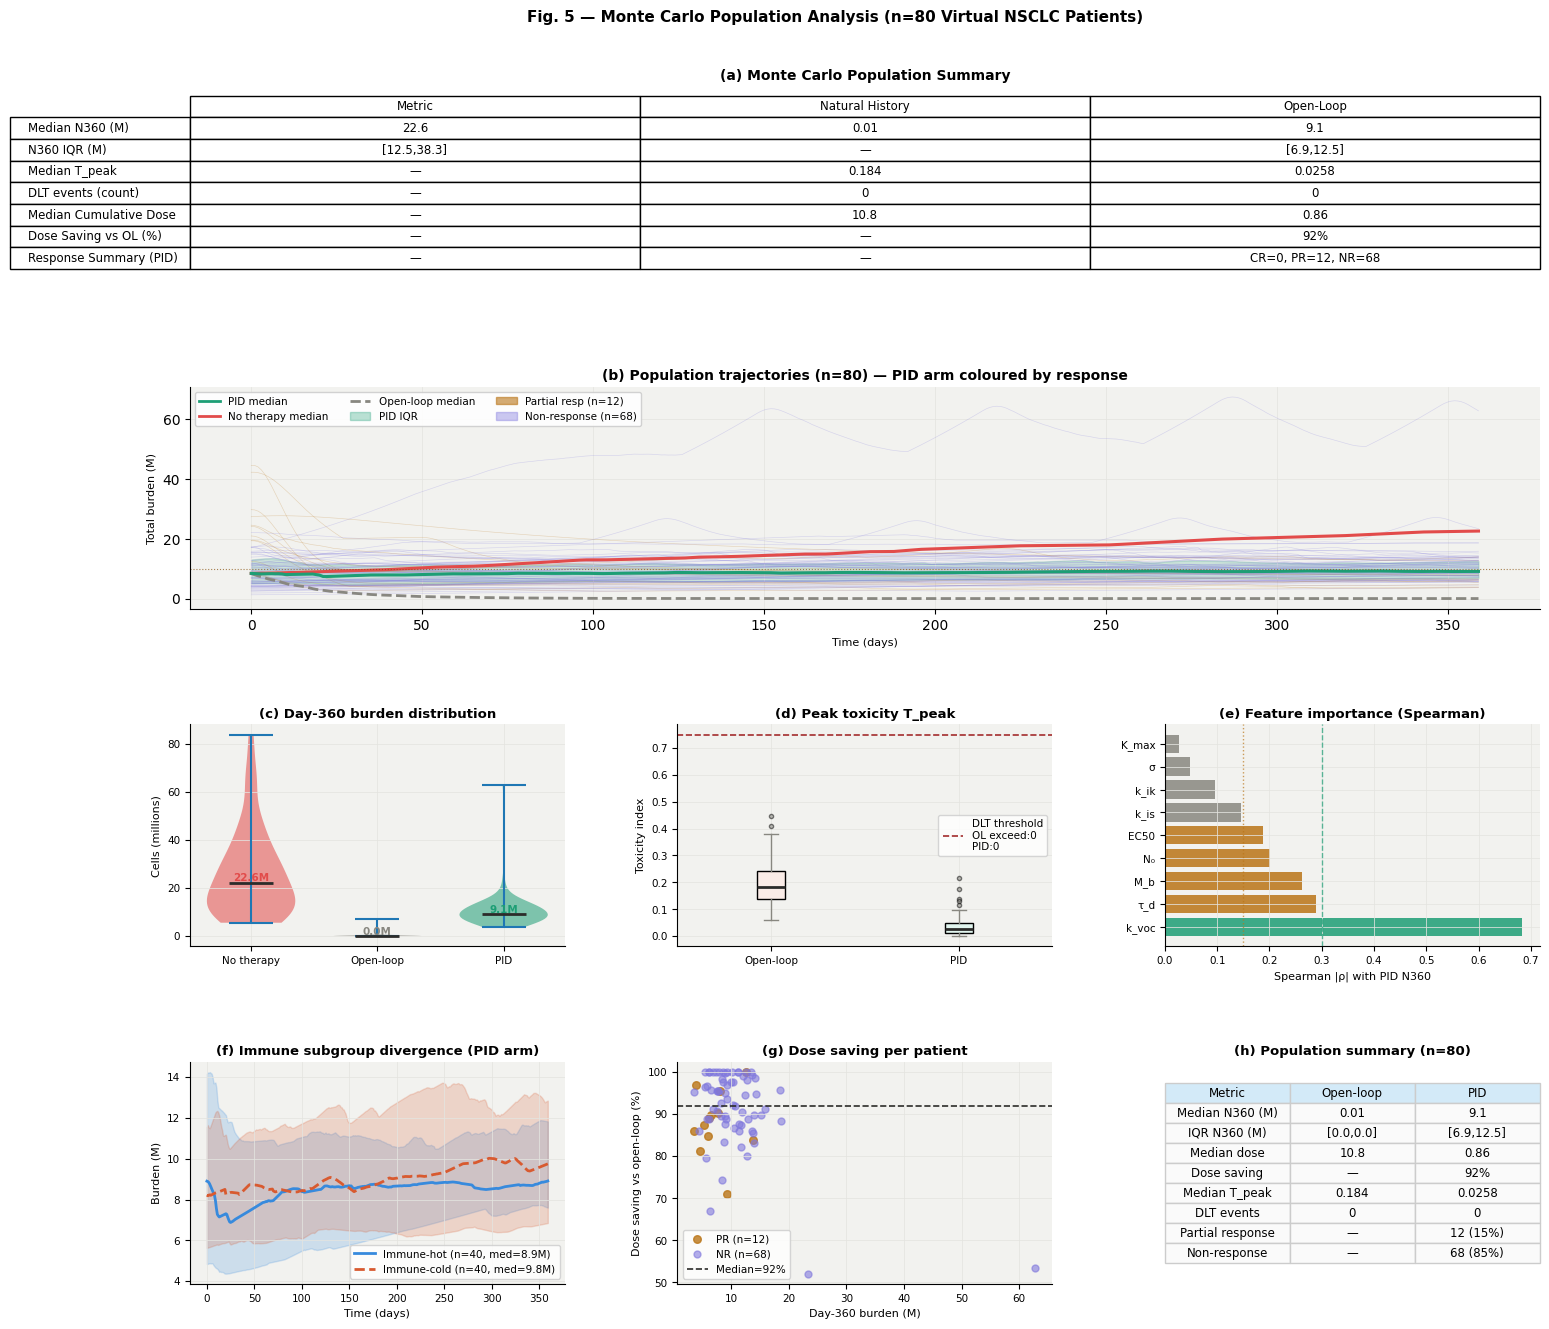

Fig. 5 saved.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Define T_DAYS for cell_11 to be self-contained
T_DAYS = 360

fig=plt.figure(figsize=(15,14)); fig.patch.set_facecolor('white')
gs=gridspec.GridSpec(4,3,hspace=0.55,wspace=0.30,height_ratios=[0.8,1,1,1],left=0.07,right=0.97,top=0.92,bottom=0.07)
t_ax=np.arange(T_DAYS)
C_pr='#BA7517'; C_nr='#7F77DD'

# Calculate saving here, before it is used in mc_data
saving=100.*(1.-Dp/Do)

# New Monte Carlo Summary Table
ax_mc_table = fig.add_subplot(gs[0,:])
ax_mc_table.axis('off') # Hide axes for the table

mc_metrics = [
    'Median N360 (M)',
    'N360 IQR (M)',
    'Median T_peak',
    'DLT events (count)',
    'Median Cumulative Dose',
    'Dose Saving vs OL (%)',
    'Response Summary (PID)'
]

mc_data = [
    [f'{np.median(N360n):.1f}', f'{np.median(N360o):.2f}', f'{np.median(N360p):.1f}'],
    [f'[{np.percentile(N360n,25):.1f},{np.percentile(N360n,75):.1f}]', '—', f'[{np.percentile(N360p,25):.1f},{np.percentile(N360p,75):.1f}]'],
    ['—', f'{np.median(Tpko):.3f}', f'{np.median(Tpkp):.4f}'],
    ['—', f'{sum(Tpko>T_thr)}', f'{sum(Tpkp>T_thr)}'],
    ['—', f'{np.median(Do):.1f}', f'{np.median(Dp):.2f}'],
    ['—', '—', f'{np.median(saving):.0f}%'],
    ['—', '—', f'CR={cr.sum()}, PR={pr.sum()}, NR={nr.sum()}']
]

# Create the table
tbl_mc = ax_mc_table.table(
    cellText=mc_data,
    rowLabels=mc_metrics,
    colLabels=['Metric', 'Natural History', 'Open-Loop', 'PID Closed-Loop'],
    loc='center',
    cellLoc='center'
)

tbl_mc.auto_set_font_size(False)
tbl_mc.set_fontsize(8.5)
tbl_mc.scale(1, 1.3) # Adjust scale for better readability
ax_mc_table.set_title('(a) Monte Carlo Population Summary', fontsize=10, fontweight='bold', pad=10)


ax1=fig.add_subplot(gs[1,:])
for i in range(N_PAT):
    ax1.plot(t_ax,r_pid[i]['traj'],color=C_pr if pr[i] else C_nr,lw=0.45,alpha=0.25)
med_n=np.median([r['traj'] for r in r_none],axis=0)
med_o=np.median([r['traj'] for r in r_ol],  axis=0)
med_p=np.median([r['traj'] for r in r_pid], axis=0)
p25=np.percentile([r['traj'] for r in r_pid],25,axis=0)
p75=np.percentile([r['traj'] for r in r_pid],75,axis=0)
ax1.fill_between(t_ax,p25,p75,color='#1D9E75',alpha=0.18,label='PID IQR')
ax1.plot(t_ax,med_n,color='#E24B4A',lw=2.2,label='No therapy (median)')
ax1.plot(t_ax,med_o,color='#888780',lw=2.,ls='--',label='Open-loop (median)')
ax1.plot(t_ax,med_p,color='#1D9E75',lw=2.2,label='PID closed-loop (median)')
ax1.axhline(10,color='#854F0B',lw=0.8,ls=':',alpha=0.7)
handles=[
    Line2D([],[],color='#1D9E75',lw=2,label='PID median'),
    Line2D([],[],color='#E24B4A',lw=2,label='No therapy median'),
    Line2D([],[],color='#888780',lw=2,ls='--',label='Open-loop median'),
    Patch(color='#1D9E75',alpha=0.30,label='PID IQR'),
    Patch(color=C_pr,alpha=0.6,label=f'Partial resp (n={pr.sum()})'),
    Patch(color=C_nr,alpha=0.4,label=f'Non-response (n={nr.sum()})')
]
ax1.legend(handles=handles,fontsize=7.5,ncol=3,framealpha=0.88,loc='upper left')
ax1.set_facecolor('#F2F2EF'); ax1.set_title(f'(b) Population trajectories (n={N_PAT}) — PID arm coloured by response',fontsize=10,fontweight='bold',pad=5)
ax1.set_xlabel('Time (days)',fontsize=8); ax1.set_ylabel('Total burden (M)',fontsize=8)
ax1.grid(color='#E4E4E0',lw=0.55); ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

def sty(ax,t,yl,xl=''):
    ax.set_facecolor('#F2F2EF'); ax.set_title(t,fontsize=9.5,fontweight='bold',pad=5)
    ax.set_ylabel(yl,fontsize=8); ax.tick_params(labelsize=7.5)
    ax.grid(color='#E4E4E0',lw=0.55); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if xl: ax.set_xlabel(xl,fontsize=8)

ax2=fig.add_subplot(gs[2,0])
vp=ax2.violinplot([N360n[N360n<100],N360o+0.001,N360p],positions=[1,2,3],showmedians=True,widths=0.7)
for b,c in zip(vp['bodies'],['#E24B4A','#888780','#1D9E75']): b.set_facecolor(c); b.set_alpha(0.55)
vp['cmedians'].set_color('#2C2C2A'); vp['cmedians'].set_linewidth(2)
ax2.set_xticks([1,2,3]); ax2.set_xticklabels(['No therapy','Open-loop','PID'],fontsize=8)
for m,c,x in zip([np.median(N360n),np.median(N360o),np.median(N360p)],['#E24B4A','#888780','#1D9E75'],[1,2,3]):
    ax2.text(x,m+0.5,f'{m:.1f}M',fontsize=7.5,ha='center',color=c,fontweight='bold')
sty(ax2,'(c) Day-360 burden distribution','Cells (millions)')

ax3=fig.add_subplot(gs[2,1])
import matplotlib
bp=ax3.boxplot([Tpko,Tpkp],tick_labels=['Open-loop','PID'],patch_artist=True,
               medianprops=dict(color='#2C2C2A',linewidth=2),
               whiskerprops=dict(color='#888780'),capprops=dict(color='#888780'),
               flierprops=dict(marker='o',markersize=3,markerfacecolor='#888780',alpha=0.5))
bp['boxes'][0].set_facecolor('#FAECE7'); bp['boxes'][1].set_facecolor('#E1F5EE')
ax3.axhline(T_thr,color='#A32D2D',lw=1.2,ls='--',label=f'DLT threshold\nOL exceed:{sum(Tpko>T_thr)}\nPID:{sum(Tpkp>T_thr)}')
ax3.legend(fontsize=7.5); sty(ax3,'(d) Peak toxicity T_peak','Toxicity index')

ax4=fig.add_subplot(gs[2,2])
pnames=['τ_d','N₀','k_voc','M_b','k_ik','k_is','EC50','K_max','σ']
pvals=np.column_stack([dts,N0s,kvocs,Mbs,kiks,kiss,ec50s,kmaxs,sigs])
corrs=[abs(stats.spearmanr(pvals[:,j],N360p).statistic) for j in range(9)]
sidx=np.argsort(corrs)[::-1]
colors_fi=['#1D9E75' if c>0.30 else '#BA7517' if c>0.15 else '#888780' for c in [corrs[i] for i in sidx]]
ax4.barh(range(9),[corrs[i] for i in sidx],color=colors_fi,alpha=0.85)
ax4.set_yticks(range(9)); ax4.set_yticklabels([pnames[i] for i in sidx],fontsize=9)
ax4.axvline(0.30,color='#1D9E75',lw=1,ls='--',alpha=0.7); ax4.axvline(0.15,color='#BA7517',lw=1,ls=':',alpha=0.7)
ax4.set_xlabel('Spearman |ρ| with PID N360',fontsize=8)
sty(ax4,'(e) Feature importance (Spearman)','')

ax5=fig.add_subplot(gs[3,0])
hot_t=[r_pid[i]['traj'] for i in range(N_PAT) if hot[i]]
cold_t=[r_pid[i]['traj'] for i in range(N_PAT) if not hot[i]]
mh=np.median(hot_t,axis=0); mc=np.median(cold_t,axis=0)
ax5.fill_between(t_ax,np.percentile(hot_t,25,axis=0),np.percentile(hot_t,75,axis=0),color='#378ADD',alpha=0.2)
ax5.fill_between(t_ax,np.percentile(cold_t,25,axis=0),np.percentile(cold_t,75,axis=0),color='#D85A30',alpha=0.2)
ax5.plot(t_ax,mh,color='#378ADD',lw=2,label=f'Immune-hot (n={hot.sum()}, med={np.median(N360p[hot]):.1f}M)')
ax5.plot(t_ax,mc,color='#D85A30',lw=2,ls='--',label=f'Immune-cold (n={(~hot).sum()}, med={np.median(N360p[~hot]):.1f}M)')
ax5.legend(fontsize=7.5); sty(ax5,'(f) Immune subgroup divergence (PID arm)','Burden (M)','Time (days)')

ax6=fig.add_subplot(gs[3,1])
ax6.scatter(N360p[pr],saving[pr],color=C_pr,s=30,alpha=0.8,label=f'PR (n={pr.sum()})')
ax6.scatter(N360p[nr],saving[nr],color=C_nr,s=25,alpha=0.6,label=f'NR (n={nr.sum()})')
ax6.axhline(np.median(saving),color='#2C2C2A',lw=1.2,ls='--',label=f'Median={np.median(saving):.0f}%')
ax6.legend(fontsize=7.5); sty(ax6,'(g) Dose saving per patient','Dose saving vs open-loop (%)','Day-360 burden (M)')

ax7=fig.add_subplot(gs[3,2]); ax7.axis('off')
rows=[['Metric','Open-loop','PID'],
      [f'Median N360 (M)',f'{np.median(N360o):.2f}',f'{np.median(N360p):.1f}'],
      ['IQR N360 (M)',f'[{np.percentile(N360o,25):.1f},{np.percentile(N360o,75):.1f}]',
       f'[{np.percentile(N360p,25):.1f},{np.percentile(N360p,75):.1f}]'],
      ['Median dose','10.8',f'{np.median(Dp):.2f}'],
      ['Dose saving','—',f'{np.median(saving):.0f}%'],
      ['Median T_peak',f'{np.median(Tpko):.3f}',f'{np.median(Tpkp):.4f}'],
      [f'DLT events',f'{sum(Tpko>T_thr)}',f'{sum(Tpkp>T_thr)}'],
      ['Partial response','—',f'{pr.sum()} ({100*pr.sum()/N_PAT:.0f}%)'],
      ['Non-response','—',f'{nr.sum()} ({100*nr.sum()/N_PAT:.0f}%)']]
tbl=ax7.table(cellText=rows[1:],colLabels=rows[0],loc='center',cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
tbl.scale(1, 1.2) # Scale the table
for (r,c),cell in tbl.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    if r==0: cell.set_facecolor('#D3EAF8')
    elif c==4 and r>0: cell.set_facecolor(verdicts.get(rows[r][4],'#FAFAFA'))
    else: cell.set_facecolor('#FAFAFA')
ax7.set_title(f'(h) Population summary (n={N_PAT})',fontsize=9.5,fontweight='bold',pad=5)

fig.suptitle(f'Fig. 5 — Monte Carlo Population Analysis (n={N_PAT} Virtual NSCLC Patients)',fontsize=11,fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.95]) # Adjust rect due to added table
plt.savefig('fig5_montecarlo.png',dpi=150,bbox_inches='tight'); plt.show(); print("Fig. 5 saved.")

# Update the figure_files list in the kernel state
figure_files = ['fig1_layer1.png', 'fig2_layer2.png', 'fig3_layer3.png', 'fig4_layer4.png', 'fig5_montecarlo.png', 'fig6_sobol.png']

## Cell 12 — Sobol Global Sensitivity Analysis



In [ ]:
# ══════════════════════════════════════════════════════
# SOBOL GLOBAL SENSITIVITY ANALYSIS
# ══════════════════════════════════════════════════════

problem = {
    'num_vars': 9,
    'names': ['Doubling time (d)','Init. burden N₀','VOC emission k_voc',
              'Warburg base M_b','Immune kill k_ik','Immune supp k_is',
              'Drug EC50','Drug K_max','Sensor noise σ'],
    'bounds': [[50,500],[1,100],[0.08,0.80],[0.08,0.25],
               [0.001,0.018],[0.70,0.95],[0.008,0.09],[0.04,0.15],[0.12,0.65]]
}

N_SOBOL = 64
param_vals = saltelli.sample(problem, N_SOBOL, calc_second_order=True)
print(f"Sobol: N={N_SOBOL}, {param_vals.shape[0]} total evaluations")

def sobol_model(X):
    Y = np.zeros((len(X), 4))
    rng_s = np.random.RandomState(42)
    for idx, params in enumerate(X):
        dt_i,N0_i,kv_i,Mb_i,kik_i,kis_i,ec50_i,kmax_i,sig_i = params
        r_i = np.log(2)/dt_i
        def ode(t,y,kr):
            N,M,V,Im,R,T=y; N=max(N,0.);M=max(M,0.);V=max(V,0.);Im=max(Im,0.);R=max(R,0.);T=max(T,0.)
            Mt=Mb_i+(1-Mb_i)*((N+R)/K)**M_POWER; eff=max(Im*(1-kis_i*M),0.)
            kill=kmax_i*(kr**h_hill)/((ec50_i**h_hill)+(kr**h_hill)) if kr>0 else 0.
            return [r_i*N*(1-(N+R)/K)-kik_i*eff*N-kill*N,(Mt-M)/tau_M,
                    kv_i*M*(N+0.7*R)-k_clear*(V-V_bg),k_ia*(N+R)*(1-kis_i*M)-k_id*Im,
                    (np.log(2)/140.)*R*(1-(N+R)/200.)+mu_res*r_i*N*max(1-(N+R)/K,0)*N,
                    k_tox*kill-k_tox_d*T]
        M0=Mb_i+(1-Mb_i)*(N0_i/K)**M_POWER; V0=min(V_bg+kv_i*M0*N0_i/k_clear,V_bg+4.)
        y=[N0_i,M0,V0,0.08,0.001,0.]; xh=V0; Pk=1.
        drift=0.; Pc=0.; Dc=0.; intg=0.; pe=0.; hol=0
        T_pk=0.; D_tot=0.; VOC_auc=0.
        for d in range(T_DAYS):
            if y[5]>=T_thr and hol==0: hol=D_HOL; Pc=0.
            sol=solve_ivp(lambda t,yy:ode(t,yy,Pc),(0,1.),y,method='RK23',rtol=1e-4,atol=1e-7,max_step=0.25)
            y=[max(v,0.) for v in sol.y[:,-1]]; N,M,V,Im,R,T=y
            S=max(V+rng_s.normal(0,sig_i)+drift+rng_s.uniform(0,0.6),0.)
            drift+=rng_s.normal(0,0.02); drift=0. if d%7==0 else drift
            Pp2=Pk+0.0025; Kg=Pp2/(Pp2+sig_i**2); xh+=Kg*(S-xh); Pk=(1-Kg)*Pp2; err=xh-(V_bg+1.2)
            if hol>0: hol=max(0,hol-24); Pc=0.
            else:
                ee=0. if abs(err)<DEAD else err-np.sign(err)*DEAD
                intg=np.clip(intg+ee,-2.,2.); deriv=ee-pe; pe=ee
                Pp=np.clip(Kp*ee+Ki*intg+Kd*deriv,0.,P_MAX)
                delta=np.clip(Pp-Pc,-P_TAP,P_TAP); Pp=np.clip(Pc+delta,0.,P_MAX)
                Dc+=Pp
                if Dc>=D_MAX: Pc=0.; hol=D_HOL; Dc=0.
                else: Pc=Pp
            T_pk=max(T_pk,T); D_tot+=Pc; VOC_auc+=V
        Y[idx]=[N+R, T_pk, D_tot, VOC_auc/T_DAYS]
        if (idx+1)%256==0: print(f"  {idx+1}/{len(X)} done")
    return Y

import time
t0=time.time()
Y_all = sobol_model(param_vals)
print(f"Evaluations complete in {(time.time()-t0)/60:.1f} min")

# Compute Sobol indices
Si_N  = sobol.analyze(problem, Y_all[:,0], calc_second_order=True, print_to_console=False)
Si_T  = sobol.analyze(problem, Y_all[:,1], calc_second_order=True, print_to_console=False)
Si_D  = sobol.analyze(problem, Y_all[:,2], calc_second_order=True, print_to_console=False)
Si_V  = sobol.analyze(problem, Y_all[:,3], calc_second_order=True, print_to_console=False)

S1 = np.clip(Si_N['S1'],0,None); ST = np.clip(Si_N['ST'],0,None)
S1c= Si_N['S1_conf'];              STc= Si_N['ST_conf']
S2 = np.clip(Si_N['S2'],0,None)

print("\nSobol indices — primary output: Day-360 N+R360")
print(f"{'Parameter':<30} {'S1':>7} {'±CI':>7} {'ST':>7} {'±CI':>7} {'ST-S1':>8} {'Class'}")
print("-"*80)
for i,nm in enumerate(problem['names']):
    cls=('Key driver' if ST[i]>0.30 else 'Interact.hub' if ST[i]-S1[i]>0.10 else
         'Moderate' if ST[i]>0.04 else 'Negligible')
    print(f"{nm:<30} {S1[i]:7.4f} {S1c[i]:7.4f} {ST[i]:7.4f} {STc[i]:7.4f} {ST[i]-S1[i]:8.4f}  {cls}")


Sobol: N=64, 1280 total evaluations
  256/1280 done
  512/1280 done
  768/1280 done
  1024/1280 done
  1280/1280 done
Evaluations complete in 5.3 min

Sobol indices — primary output: Day-360 N+R360
Parameter                           S1     ±CI      ST     ±CI    ST-S1 Class
--------------------------------------------------------------------------------
Doubling time (d)               0.3380  0.3725  0.3479  0.3175   0.0099  Key driver
Init. burden N₀                 0.0266  0.0298  0.0186  0.0265  -0.0080  Negligible
VOC emission k_voc              0.6411  0.3739  0.5701  0.2102  -0.0710  Key driver
Warburg base M_b                0.0275  0.0422  0.0139  0.0080  -0.0136  Negligible
Immune kill k_ik                0.0256  0.1198  0.2194  0.2006   0.1938  Interact.hub
Immune supp k_is                0.0192  0.0430  0.0107  0.0133  -0.0084  Negligible
Drug EC50                       0.0604  0.0807  0.0634  0.0461   0.0030  Moderate
Drug K_max                      0.0258  0.0527  0.0217 

## Cell 13 — Figure 6: Sobol Global Sensitivity Analysis

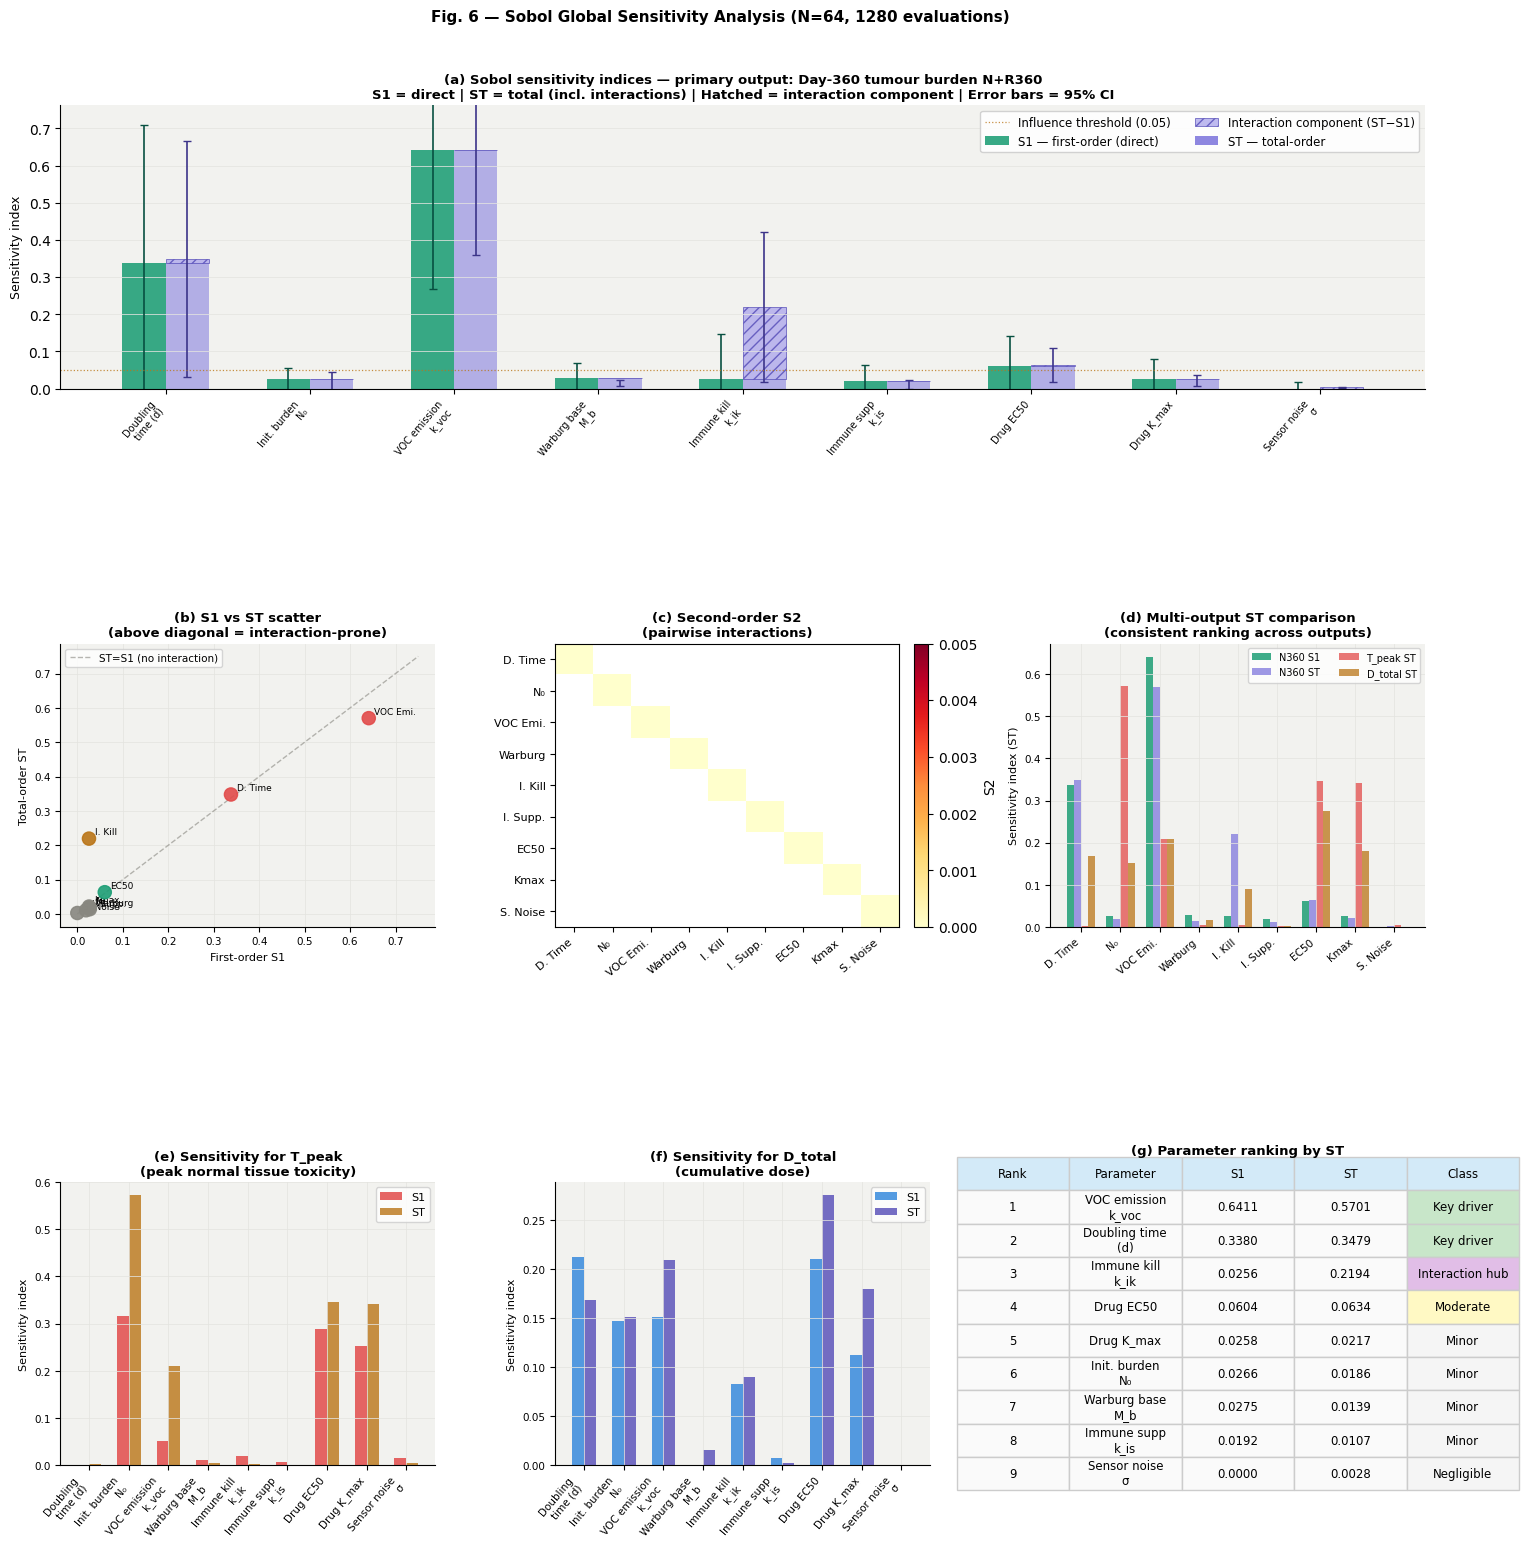

Fig. 6 saved.


In [ ]:
fig=plt.figure(figsize=(15,16)); fig.patch.set_facecolor('white')
gs=gridspec.GridSpec(3,3,hspace=0.9,wspace=0.32,left=0.06,right=0.97,top=0.92,bottom=0.07)

x=np.arange(9); w=0.30
# Updated pshort for clarity on bar charts (ax1, ax5, ax6)
pshort = [
    'Doubling\ntime (d)', 'Init. burden\nN₀', 'VOC emission\nk_voc',
    'Warburg base\nM_b', 'Immune kill\nk_ik', 'Immune supp\nk_is',
    'Drug EC50', 'Drug K_max', 'Sensor noise\nσ'
]
# Updated short for conciseness on heatmap and scatter annotation (ax2, ax3, ax4)
short = [
    'D. Time', 'N₀', 'VOC Emi.', 'Warburg',
    'I. Kill', 'I. Supp.', 'EC50', 'Kmax', 'S. Noise'
]
# Custom names for the table in ax7 to ensure no truncation and better line breaks
table_param_names = [
    'Doubling time\n(d)',
    'Init. burden\nN₀',
    'VOC emission\nk_voc',
    'Warburg base\nM_b',
    'Immune kill\nk_ik',
    'Immune supp\nk_is',
    'Drug EC50',
    'Drug K_max',
    'Sensor noise\nσ'
]

# Panel 1: S1 + ST main chart
ax1=fig.add_subplot(gs[0,:])
interact=np.clip(ST-S1,0,None)
b1=ax1.bar(x-w/2, S1,  w, color='#1D9E75', alpha=0.88, label='S1 — first-order (direct)')
b2=ax1.bar(x+w/2, S1,  w, color='#7F77DD', alpha=0.55)
b3=ax1.bar(x+w/2, interact, w, bottom=S1, color='#AFA9EC', alpha=0.80, hatch='///',
           edgecolor='#534AB7', lw=0.6, label='Interaction component (ST−S1)')
ax1.bar(x+w/2, [0]*9, w, color='#7F77DD', alpha=0.88, label='ST — total-order')
ax1.errorbar(x-w/2, S1, yerr=S1c, fmt='none', color='#085041', capsize=3, lw=1.2)
ax1.errorbar(x+w/2, ST, yerr=STc, fmt='none', color='#3C3489', capsize=3, lw=1.2)
ax1.axhline(0.05, color='#BA7517', lw=0.9, ls=':', alpha=0.8, label='Influence threshold (0.05)')
ax1.set_xticks(x); ax1.set_xticklabels(pshort, fontsize=7, rotation=50, ha='right') # Using updated pshort and rotation, adjusted fontsize/rotation
ax1.legend(fontsize=8.5, ncol=2, framealpha=0.88, loc='upper right')
ax1.set_ylabel('Sensitivity index', fontsize=9); ax1.set_ylim(0, min(1.0, max(ST)*1.25+0.05))
ax1.set_facecolor('#F2F2EF'); ax1.set_title('(a) Sobol sensitivity indices — primary output: Day-360 tumour burden N+R360\nS1 = direct | ST = total (incl. interactions) | Hatched = interaction component | Error bars = 95% CI',
                fontsize=9.5, fontweight='bold', pad=5)
ax1.grid(color='#E4E4E0', lw=0.55, axis='y')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

def sty(ax,t,yl,xl=''):
    ax.set_facecolor('#F2F2EF'); ax.set_title(t,fontsize=9.5,fontweight='bold',pad=5)
    ax.set_ylabel(yl,fontsize=8); ax.tick_params(labelsize=7.5)
    ax.grid(color='#E4E4E0',lw=0.55); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if xl: ax.set_xlabel(xl,fontsize=8)

# S1 vs ST scatter
ax2=fig.add_subplot(gs[1,0])
dot_c=['#E24B4A' if st>0.30 else '#BA7517' if st>0.10 else '#1D9E75' if st>0.04 else '#888780' for st in ST]
ax2.scatter(S1,ST,s=90,c=dot_c,zorder=4,alpha=0.9)
ax2.plot([0,0.75],[0,0.75],color='#888780',lw=1.,ls='--',alpha=0.6,label='ST=S1 (no interaction)')
for i,(s1i,sti) in enumerate(zip(S1,ST)):
    ax2.annotate(short[i],(s1i,sti),xytext=(4,3),textcoords='offset points',fontsize=6.5) # Using updated short
ax2.legend(fontsize=7.5); ax2.set_xlabel('First-order S1',fontsize=8)
sty(ax2,'(b) S1 vs ST scatter\n(above diagonal = interaction-prone)','Total-order ST')

# S2 heatmap
ax3=fig.add_subplot(gs[1,1])
S2s=S2+S2.T; np.fill_diagonal(S2s,0.); S2s=np.clip(S2s,0,None)
im=ax3.imshow(S2s,cmap='YlOrRd',aspect='auto',vmin=0,vmax=max(0.005,S2s.max()))
plt.colorbar(im,ax=ax3,fraction=0.044,pad=0.04,label='S2')
ax3.set_xticks(range(9)); ax3.set_xticklabels(short,rotation=40,ha='right',fontsize=8) # Using updated short
ax3.set_yticks(range(9)); ax3.set_yticklabels(short,fontsize=8) # Using updated short
ax3.set_title('(c) Second-order S2\n(pairwise interactions)',fontsize=9.5,fontweight='bold',pad=5)

# Multi-output ST
ax4=fig.add_subplot(gs[1,2])
S1t=np.clip(Si_T['S1'],0,None); STt=np.clip(Si_T['ST'],0,None)
S1d=np.clip(Si_D['S1'],0,None); STd=np.clip(Si_D['ST'],0,None)
w4=0.18
ax4.bar(x-w4*1.5,S1,  w4,color='#1D9E75',alpha=0.85,label='N360 S1')
ax4.bar(x-w4*0.5,ST,  w4,color='#7F77DD',alpha=0.75,label='N360 ST')
ax4.bar(x+w4*0.5,STt, w4,color='#E24B4A',alpha=0.75,label='T_peak ST')
ax4.bar(x+w4*1.5,STd, w4,color='#BA7517',alpha=0.75,label='D_total ST')
ax4.set_xticks(x); ax4.set_xticklabels(short,fontsize=8, rotation=40, ha='right'); ax4.legend(fontsize=7,ncol=2) # Using updated short and rotation
sty(ax4,'(d) Multi-output ST comparison\n(consistent ranking across outputs)','Sensitivity index (ST)')

# Toxicity sensitivity
ax5=fig.add_subplot(gs[2,0])
ax5.bar(x-w/2,np.clip(Si_T['S1'],0,None),w,color='#E24B4A',alpha=0.85,label='S1')
ax5.bar(x+w/2,STt,w,color='#BA7517',alpha=0.80,label='ST')
ax5.set_xticks(x); ax5.set_xticklabels(pshort,fontsize=7, rotation=50, ha='right'); ax5.legend(fontsize=8) # Using updated pshort and rotation, adjusted fontsize/rotation
sty(ax5,'(e) Sensitivity for T_peak\n(peak normal tissue toxicity)','Sensitivity index')

# Dose sensitivity
ax6=fig.add_subplot(gs[2,1])
ax6.bar(x-w/2,S1d,w,color='#378ADD',alpha=0.85,label='S1')
ax6.bar(x+w/2,STd,w,color='#534AB7',alpha=0.80,label='ST')
ax6.set_xticks(x); ax6.set_xticklabels(pshort,fontsize=7, rotation=50, ha='right'); ax6.legend(fontsize=8) # Using updated pshort and rotation, adjusted fontsize/rotation
sty(ax6,'(f) Sensitivity for D_total\n(cumulative dose)','Sensitivity index')

# Ranking table
ax7=fig.add_subplot(gs[2,2]); ax7.axis('off')
sidx_sobol=np.argsort(ST)[::-1]
rows=[['Rank','Parameter','S1','ST','Class']]
verdicts={'Key driver':'#C8E6C9','Moderate':'#FFF9C4','Interaction hub':'#E1BEE7','Negligible':'#F5F5F5','Minor':'#F5F5F5'}
for rank,i in enumerate(sidx_sobol):
    cls=('Key driver' if ST[i]>0.30 else 'Interaction hub' if ST[i]-S1[i]>0.10 else
         'Moderate' if ST[i]>0.04 else 'Minor' if ST[i]>0.01 else 'Negligible')
    rows.append([str(rank+1),table_param_names[i],f'{S1[i]:.4f}',f'{ST[i]:.4f}',cls]) # Using table_param_names
tbl=ax7.table(cellText=rows[1:],colLabels=rows[0],loc='center',cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
tbl.scale(1.5, 2.0) # Scale the table
for (r,c),cell in tbl.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    if r==0: cell.set_facecolor('#D3EAF8')
    elif c==4 and r>0: cell.set_facecolor(verdicts.get(rows[r][4],'#FAFAFA'))
    else: cell.set_facecolor('#FAFAFA')
ax7.set_title('(g) Parameter ranking by ST',fontsize=9.5,fontweight='bold',pad=20)

fig.suptitle(f'Fig. 6 — Sobol Global Sensitivity Analysis (N={N_SOBOL}, {param_vals.shape[0]} evaluations)',
             fontsize=11,fontweight='bold')
plt.savefig('fig6_sobol.png',dpi=150,bbox_inches='tight'); plt.show(); print("Fig. 6 saved.")

In [ ]:
import zipfile

zip_filename = 'all_figures.zip'
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for fig_file in figure_files:
        zipf.write(fig_file)

from google.colab import files
files.download(zip_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>